In [1]:
import sys, os; sys.path.insert(0, os.path.join("..", "src")) if os.path.basename(os.getcwd())=="notebooks" else sys.path.insert(0, "src")
import config, data_layer, econometrics as ek, validate, outputs

# FR09 — İnflyasiya (İstehlak Qiymətləri İndeksi)

İstehlak qiymətlərinin orta illik indeksinin (inflyasiya) təhlili və proqnozlaşdırılması
(MİİS §15.5.1, bənd 2.4.1.5.-7.; hüquqi əsas — Nazirlər Kabinetinin 24.05.2004 tarixli 75 nömrəli
qərarı, bənd 2.4.1).

## 1. Tələb

**Spesifikasiyanın mətni (§15.5.1, FR9):** "İstehlak qiymətlərinin orta illik indeksinin (inflyasiya)
təhlili və proqnozlaşdırılması."

Tələbin diqqət yetirilməli iki elementi var. Birincisi, hesabat vahidi **orta illik** indeksdir — yəni
dekabrdan dekabra ölçülən nöqtə göstəricisi deyil, il ərzindəki bütün ayların qiymət səviyyəsinin əvvəlki
ilin müvafiq orta səviyyəsi ilə müqayisəsidir; büdcə hesablamaları, əmək haqqı indeksləşdirilməsi və
deflyator zəncirləri məhz bu kəmiyyətlə işlədiyi üçün paketdə də yeganə baş göstərici olaraq o
götürülür. İkincisi, tələb yalnız proqnozu deyil, **təhlili** də əhatə edir: inflyasiyanın strukturunun
(ərzaq, qeyri-ərzaq, ödənişli xidmətlər) və onun hansı xarici amillərlə hərəkət etdiyinin göstərilməsi
tələbin ayrılmaz hissəsidir.

İcra ardıcıllığında (BUILD_CONTEXT §D2) bu dəftər FR5 (neftin dünya qiyməti) və FR10 (valyuta məzənnəsi)
mərhələlərindən sonra, lakin FR1 (ÜDM nüvəsi) mərhələsindən əvvəl yerləşir. Səbəb odur ki, inflyasiya
yolu bir tərəfdən neft qiyməti və məzənnə rejimi ilə şərtlənir, digər tərəfdən isə özü aşağı axın
üçün **ekzogen fərziyyə** rolunu oynayır: qeyri-neft deflyatoru, əhalinin real gəlirləri və sahə
deflyatorları bu dəftərin yazdığı `cpi_infl` yolundan qidalanır.

## 2. Məlumat

İstifadə olunan sıralar (faktiki dəyərlər yalnız `data_layer.actuals(...)` vasitəsilə oxunur və
HƏMİŞƏ ≤ 2025 ilində bitir):

| `series_code` | Təsvir | Vahid | Mənbə | Əhatə |
|---|---|---|---|---|
| `cpi_infl` | İnflyasiya (İQİ, orta illik) | % | `macro_annual.csv`; 2025 üçün DSK-nın rəsmi nəticəsi; statutar şablon 2.4.1.5.-7., sətir 54 | 1992–2025 |
| `cpi_index` | İstehlak qiymətlərinin bazis indeksi | indeks | `model_series_annual.csv` | 1995–2025 |
| `brent_usd` | Neftin dünya bazarında qiyməti (Brent) | USD/barel | Neft-Qaz sektoru, sətir 11 | 1991–2025 |
| `import_price_infl` | İdxal qiymətlərinin artımı | % | `external_block_annual.csv` | 2000–2025 |
| `neer` (xarici blok) | Nominal Effektiv Məzənnə (NEER) | indeks | `external_block_annual.csv` | 2000–2025 |
| `money_r029` | M2 pul aqreqatı (aylıqdan illiyə) | mln manat | Monetar sektoru, sətir 29 | 2006–2025 |
| `money_r087/088/089` | İllik inflyasiya: ərzaq / qeyri-ərzaq / ödənişli xidmətlər | % | Monetar sektoru, sətirlər 87–89 | 2000–2025 |

Proqnoz üfüqünün girişləri (yuxarı axının nəticəsi, `data/assumptions.csv`): `brent_usd` (FR5-in öz
modelinin nəticəsi) və `usd_azn` (FR10-un rejim fərziyyəsi). Nazirliyin 2026–2030 Proqnoz sütunları
yalnız `ministry_baseline(...)` vasitəsilə, müqayisə məqsədi ilə oxunur və heç bir reqressiyaya daxil
edilmir.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.filters.hp_filter import hpfilter

pd.set_option("display.width", 200)
LA, FY = config.LAST_ACTUAL, list(config.FY)          # 2025 və 2026–2030

cpi_infl = data_layer.actuals("cpi_infl")             # baş göstərici: orta illik inflyasiya, %
cpi_index_pub = data_layer.actuals("cpi_index")       # nəşr olunmuş bazis indeksi (2015 = 1,000)
brent = data_layer.actuals("brent_usd")               # FR5-in faktiki sırası
imp_infl = data_layer.actuals("import_price_infl")    # ekzogen: idxal qiymətlərinin artımı

ext = data_layer.external_block().set_index("year")
neer_hist = ext["neer"].loc[:LA]                      # NEER yalnız faktiki hissəsi ilə götürülür
neer_file_fc = ext["neer"].loc[config.FIRST_FORECAST:]  # faylın öz baza yolu — YALNIZ həssaslıq üçün

print("cpi_infl, son on il:")
print(cpi_infl.loc[2016:].round(2).to_string())
print(f"\nəhatə: {int(cpi_infl.index.min())}–{int(cpi_infl.index.max())}, n = {len(cpi_infl)}")
print(f"NEER (xarici blok), faktiki: {int(neer_hist.index.min())}–{int(neer_hist.index.max())}")

cpi_infl, son on il:
year
2016    12.40
2017    12.90
2018     2.30
2019     2.60
2020     2.76
2021     6.70
2022    13.90
2023     8.80
2024     2.20
2025     5.60

əhatə: 1992–2025, n = 34
NEER (xarici blok), faktiki: 2000–2025


**2025-ci ilin bazası.** 2025 üçün orta illik inflyasiya DSK-nın 2026-01-19 tarixli rəsmi buraxılışından
götürülür (5,6 %); `macro_annual.csv` sırası bu ildə rəsmi göstərici ilə əvəzlənir. Aşağıda hər ilin
provenansı çap olunur ki, hansı dəyərin hansı mənbədən gəldiyi mübahisə obyekti olmasın.

In [3]:
prov = data_layer.actuals_source("cpi_infl")
print("cpi_infl provenansı (son altı il):")
print(prov.loc[2020:].to_string())

# İş kitabının aylıq monetar bloku ilə tutuşdurma. DİQQƏT — sətir 86-nın illik xanası aylıq
# müşahidələrin ORTALAMASI DEYİL: aylıq sıra yanvar–noyabr aylarını daşıyır, illik xana isə həmin
# sıranın DEKABR müşahidəsidir, yəni **dövrün sonuna** (dekabrdan dekabra) 12 aylıq inflyasiyadır.
# Bu, DSK-nın orta illik göstəricisindən fərqli ANLAYIŞDIR (eyni fərq FR10-da məzənnə üçün
# sənədləşdirilib). Aşağıda hər iki oxunuş yan-yana verilir ki, fərqin mənbəyi görünsün.
wb_yoy = data_layer.wb_annual("money_r086")                       # dekabr, 12 aylıq
_wb_m = data_layer.monthly("money_r086")                          # yanvar–noyabr
_wb_m_avg = (_wb_m.groupby("year")["value"].mean() - 100.0)       # aylıq ortalama (fərqli kəmiyyət)

cmp_2025 = pd.DataFrame({
    "iş kitabı, sətir 86 (DEKABR, 12 aylıq)": (wb_yoy.loc[2020:LA] - 100.0).round(2),
    "eyni sətrin yan–noy ortalaması": _wb_m_avg.loc[2020:LA].round(2),
    "DSK rəsmi ORTA İLLİK (cpi_infl)": cpi_infl.loc[2020:LA].round(2),
})
cmp_2025["dekabr − orta illik (p.b.)"] = (cmp_2025.iloc[:, 0] - cmp_2025.iloc[:, 2]).round(2)
print("sətir 86-nın aylıq sırası:", f"{int(_wb_m['month'].min())}–{int(_wb_m['month'].max())} ay, "
      f"illik xana isə aylıq ortalamadan {(wb_yoy.loc[2020:LA] - 100.0 - _wb_m_avg.loc[2020:LA]).abs().max():.1f} "
      "faiz bəndinə qədər fərqlənir → illik xana ORTALAMA deyil")
cmp_2025

cpi_infl provenansı (son altı il):
year
2020    csv:macro_annual.csv:cpi_infl
2021    csv:macro_annual.csv:cpi_infl
2022    csv:macro_annual.csv:cpi_infl
2023    csv:macro_annual.csv:cpi_infl
2024    csv:macro_annual.csv:cpi_infl
2025        official_2025_actuals.csv
sətir 86-nın aylıq sırası: 1–11 ay, illik xana isə aylıq ortalamadan 7.5 faiz bəndinə qədər fərqlənir → illik xana ORTALAMA deyil


,"iş kitabı, sətir 86 (DEKABR, 12 aylıq)",eyni sətrin yan–noy ortalaması,DSK rəsmi ORTA İLLİK (cpi_infl),dekabr − orta illik (p.b.)
year,,,,
2020,2.6,NaN,2.76,-0.16
2021,12.0,6.16,6.70,5.30
2022,14.4,13.78,13.90,0.50
2023,2.1,9.56,8.80,-6.70
2024,4.9,1.98,2.20,2.70
2025,5.2,5.67,5.60,-0.40


İki ölçmə arasındakı fərq **hesablama qaydasından deyil, ANLAYIŞ fərqindən** irəli gəlir və bəzi
illərdə çox böyükdür: 2023-cü ildə 6,7, 2021-ci ildə 5,3 faiz bəndi (2025-ci ildə isə cəmi
0,4 faiz bəndi — yəni tək bir ilin yaxınlığına söykənmək olmaz).

İş kitabının 86-cı sətrinin illik xanası **dövrün sonuna** göstəricidir: dekabrın əvvəlki ilin
dekabrına nisbətdə 12 aylıq artımı. DSK-nın rəsmi göstəricisi isə il ərzindəki **orta qiymət
səviyyəsinin** əvvəlki ilin orta səviyyəsinə nisbətidir. İki kəmiyyət yalnız qiymətlərin il ərzində
sabit sürətlə hərəkət etdiyi illərdə yaxınlaşır; sürət il ərzində dönəndə (2021-də sürətlənmə,
2023-də kəskin yavaşlama) onlar sistematik olaraq ayrılır. Bu, FR10-da AZN/USD üçün sənədləşdirilmiş
«orta illik ↔ dövrün sonuna» ayrımının eynisidir.

Spesifikasiya (§15.5.1, FR9) açıq şəkildə **orta illik** indeksi tələb etdiyi üçün paket boyu rəsmi
orta illik göstərici istifadə olunur (BUILD_CONTEXT §7 — 2025 bazası bir dəfə təyin edilir); iş
kitabının sətri isə yalnız **ikinci, fərqli anlayışlı ölçmə** kimi göstərilir və uzlaşma sınağı
sayılmır.


### 2.1. İnflyasiyanın strukturu

Tələbin təhlil hissəsi üçün İQİ-nin üç əsas gövdəsi ayrıca izlənilir: ərzaq məhsulları (içkilər və tütün
daxil), qeyri-ərzaq məhsulları və ödənişli xidmətlər. Bu sətirlər əsas iş kitabının Monetar sektoru
vərəqindən (87–89) götürülür.

**Vahid qeydi.** 86–89-cu sətirlərin illik xanaları — 86-cı sətirdə olduğu kimi — **dekabrdan dekabra**
12 aylıq artımdır, aylıq müşahidələrin ortalaması deyil (yuxarıda ədədlə göstərildi). Ona görə aşağıdakı
struktur cədvəli baş göstərici ilə eyni vahiddə DEYİL: o, qrupların dövrün sonuna qiymət hərəkətini
göstərir. Cədvəl yalnız **strukturun** (hansı qrupun daha çox hərəkət etdiyinin) təsviri üçündür; heç bir
tənliyə daxil olmur və baş göstərici (orta illik `cpi_infl`) ondan törəmir. Dörd sütun da eyni anlayışda
olduğu üçün onların bir-biri ilə müqayisəsi düzgündür.

In [4]:
struct = pd.DataFrame({
    "ərzaq": data_layer.wb_annual("money_r087") - 100.0,
    "qeyri-ərzaq": data_layer.wb_annual("money_r088") - 100.0,
    "ödənişli xidmətlər": data_layer.wb_annual("money_r089") - 100.0,
    "ümumi (sətir 86)": data_layer.wb_annual("money_r086") - 100.0,
}).loc[2013:LA].round(2)
# DİQQƏT: dörd sütunun hamısı DEKABRDAN DEKABRA 12 aylıq artımdır (aylıq ortalama deyil) —
# baş göstəricinin orta illik dəyərləri ilə birbaşa müqayisə olunmamalıdır (§2, §9).
struct

,ərzaq,qeyri-ərzaq,ödənişli xidmətlər,ümumi (sətir 86)
year,,,,
2013,2.9,3.5,4.2,3.5
2014,-0.5,0.2,-0.1,-0.1
2015,9.2,11.0,2.5,7.6
2016,21.0,16.2,8.1,15.7
2017,9.4,7.0,6.7,7.9
2018,0.3,1.2,3.4,1.5
2019,4.2,1.0,0.9,2.4
2020,4.5,1.2,1.1,2.6
2021,15.8,7.7,10.0,12.0


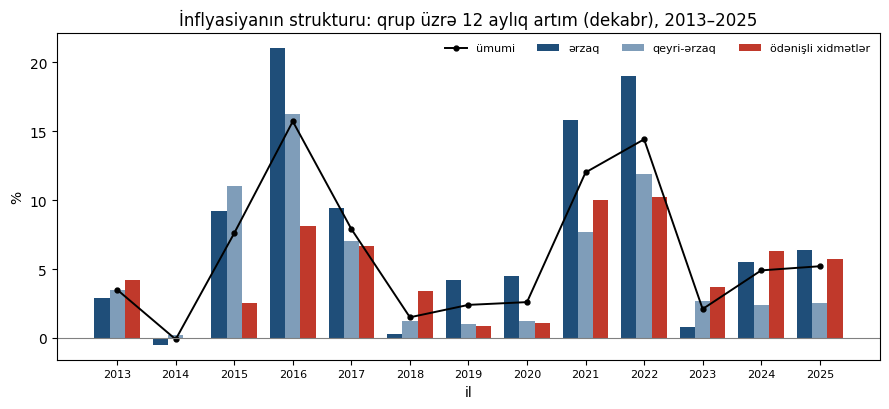

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.2))
w = 0.26
xs = np.arange(len(struct.index))
for i, (col, colr) in enumerate([("ərzaq", "#1f4e79"), ("qeyri-ərzaq", "#7f9db9"),
                                 ("ödənişli xidmətlər", "#c0392b")]):
    ax.bar(xs + (i - 1) * w, struct[col].values, width=w, label=col, color=colr)
ax.plot(xs, struct["ümumi (sətir 86)"].values, "k-o", ms=3.5, lw=1.4, label="ümumi")
ax.axhline(0, color="grey", lw=0.8)
ax.set_xticks(xs); ax.set_xticklabels([str(int(y)) for y in struct.index], rotation=0, fontsize=8)
ax.set_title("İnflyasiyanın strukturu: qrup üzrə 12 aylıq artım (dekabr), 2013–2025")
ax.set_ylabel("%"); ax.set_xlabel("il")
ax.legend(frameon=False, fontsize=8, ncol=4)
fig.tight_layout()
fig.savefig(os.path.join(config.FIG, "FR09_struktur.png"), dpi=140)
plt.show()

Struktur mənzərəsi üç dövrü aydın ayırır (bütün rəqəmlər **dekabrdan dekabra**, ona görə baş
göstəricinin orta illik dəyərləri ilə birbaşa müqayisə olunmamalıdır). 2015–2016-cı illərdə devalvasiyanın zərbəsi ən çox **ticarət
olunan** mallara düşüb: ərzaq qiymətləri 2016-cı ildə 21 %, qeyri-ərzaq 16,2 % artdığı halda ödənişli
xidmətlər 8,1 % ilə məhdudlaşıb. 2021–2022-ci illərin qlobal ərzaq və enerji şoku eyni ardıcıllığı
təkrarlayıb (ərzaq 19,0 %, qeyri-ərzaq 11,9 %). 2023-cü ildən sonra isə mənzərə tərsinə çevrilib:
qeyri-ərzaq artımı 2,4–2,5 %-ə enib, ödənişli xidmətlər isə 5,7–6,3 % səviyyəsində qalıb — yəni qalıq
inflyasiya artıq idxal olunan mal qiymətlərindən deyil, daxili xidmət və əmək haqqı təzyiqindən
qidalanır. Bu müşahidə aşağıdakı model seçimi üçün birbaşa əhəmiyyət daşıyır.

## 3. Model seçimi

Baş tənlik **açıq iqtisadiyyat üçün Filips əyrisi** (Phillips curve) formasında qurulur:

$$\pi_t = \alpha + \beta_1 \pi_{t-1} + \beta_2 \Delta \ln P^{\text{Brent}}_t
        + \beta_3 \Delta \ln \text{NEER}_t + \delta D^{15\text{--}16}_t + \varepsilon_t$$

Tənliyin dörd elementi Azərbaycan məlumatının strukturuna uyğun seçilib. **Gecikmiş inflyasiya**
($\pi_{t-1}$) gözləntilərin ətalətini və qiymət düzəlişlərinin bir illik yayılmasını daşıyır.
**Neftin dünya qiymətinin loq fərqi** xərc kanalını təmsil edir: neft həm idxal olunan yanacaq və
nəqliyyat xərcləri vasitəsilə birbaşa, həm də büdcə xərcləri və tələb vasitəsilə dolayısı ilə daxili
qiymətlərə ötürülür. **NEER-in loq fərqi** ötürülmə (pass-through) kanalıdır — effektiv məzənnənin
möhkəmlənməsi idxal qiymətlərini manatla ucuzlaşdırır, ona görə $\beta_3 < 0$ gözlənilir.
**$D^{15-16}$** 2015–2016-cı illərin iki devalvasiyasını nişanlayan süni dəyişəndir; onsuz həmin iki il
qalıqları elə böyüdür ki, digər əmsalların qiymətləndirilməsi etibarsızlaşır (§0-ın sınıq nöqtə qaydası,
n ≥ 15 şərti bu nümunədə ödənilir).

Nümunə **2005–2025** (n = 21) götürülür. Bu seçimin səbəbi budur: 1990-cı illərin hiperinflyasiyası
(1994-cü ildə 1662 %) və 1998–1999-cu illərin deflyasiyası tamamilə fərqli pul rejiminə aiddir və
onların nümunəyə daxil edilməsi əmsalları həmin dövrün dinamikası ilə müəyyən edərdi; 2005-ci il isə
neft gəlirlərinin sistematik axınının başladığı və indiki qiymət mexanizminin formalaşdığı ildir.
Seçimin özbaşına olmadığını göstərmək üçün aşağıda eyni tənlik **2001–2025** (n = 25) nümunəsində də
qiymətləndirilir və hər iki nəticə açıq müqayisə olunur.

Model seçimi qərarından **sonra** iki diaqnostik genişləndirmə yoxlanılır: məhsul buraxılışı fərqi
(output gap) və real pul kütləsinin artımı. Bu ardıcıllığın qeyd olunması vacibdir — genişləndirmə
spesifikasiyanı seçmək üçün deyil, seçilmiş spesifikasiyanın nəyi kənarda qoyduğunu ölçmək üçün aparılır.

In [6]:
# --- çevrilmələr: bütün sürücülər loq fərq (%) formasındadır -----------------
dlb = (np.log(brent).diff() * 100.0).rename("dlb")            # Δln Brent, %
dln = (np.log(neer_hist).diff() * 100.0).rename("dln")        # Δln NEER, %
d1516 = pd.Series(0.0, index=range(1990, config.LAST_FORECAST + 1), name="d1516")
d1516.loc[[2015, 2016]] = 1.0                                 # 2015–2016 devalvasiyası

S = pd.DataFrame({
    "y": cpi_infl,
    "pi_l1": cpi_infl.shift(1),
    "dlb": dlb, "dln": dln,
    "dlb_l1": dlb.shift(1), "dln_l1": dln.shift(1),
    "d1516": d1516,
})
S = S.loc[:LA]                    # struktur mühafizə: cədvəl 2025-də bitir
print(S.loc[2013:].round(2).to_string())

          y  pi_l1    dlb    dln  dlb_l1  dln_l1  d1516
2013   2.40   1.10  -2.79   1.52    0.33    4.50    0.0
2014   1.40   2.40  -9.25   6.44   -2.79    1.52    0.0
2015   4.00   1.40 -63.74  -5.64   -9.25    6.44    1.0
2016  12.40   4.00 -18.14 -39.01  -63.74   -5.64    1.0
2017  12.90  12.40  21.54  -5.78  -18.14  -39.01    0.0
2018   2.30  12.90  27.61   7.68   21.54   -5.78    0.0
2019   2.60   2.30 -10.39   7.53   27.61    7.68    0.0
2020   2.76   2.60 -42.68   8.99  -10.39    7.53    0.0
2021   6.70   2.76  52.40   8.36  -42.68    8.99    0.0
2022  13.90   6.70  35.37  30.78   52.40    8.36    0.0
2023   8.80  13.90 -20.18  22.71   35.37   30.78    0.0
2024   2.20   8.80  -2.42  22.86  -20.18   22.71    0.0
2025   5.60   2.20 -15.24  17.89   -2.42   22.86    0.0


## 4. Testlər

Bütün tənliklər **fərq/temp** səviyyəsində qurulduğu üçün (asılı dəyişən artıq artım tempidir, sürücülər
isə loq fərqlərdir) səviyyə reqressiyası yoxdur və ona görə baş tənlikdə kointeqrasiya sınağına ehtiyac
qalmır. Buna baxmayaraq, aşağıda pul kütləsi ilə qiymət səviyyəsi arasında uzunmüddətli əlaqənin
mövcudluğu **`ek.eg_coint`** ilə ayrıca yoxlanılır, çünki diaqnostik bölmədə pul dəyişəninin hansı
formada (səviyyə, yoxsa artım tempi) daxil ediləcəyi məhz bu nəticədən asılıdır.

**Gecikmə seçimi haqqında qeyd.** Bu uzunluqda (n ≈ 21–25) illik nümunədə ADF-in avtomatik gecikmə
seçimi standart maksimumla (≈ 8) işlədikdə nümunənin böyük hissəsini gecikmələrə sərf edir və
statistikanı mənasızlaşdırır. Ona görə maksimal gecikmə açıq şəkildə 2 ilə məhdudlaşdırılır; bu, illik
məlumat üçün iqtisadi cəhətdən də kifayət qədər genişdir.

In [7]:
tests = [
    ek.adf(S.loc[2000:LA, "y"], "cpi_infl, 2000–2025", maxlag=2),
    ek.adf(S.loc[2005:LA, "y"], "cpi_infl, 2005–2025", maxlag=2),
    ek.adf(S.loc[2001:LA, "dlb"].dropna(), "Δln Brent, 2001–2025", maxlag=2),
    ek.adf(S.loc[2001:LA, "dln"].dropna(), "Δln NEER, 2001–2025", maxlag=2),
]
for t in tests:
    print(t)
print()
for t in tests[:2]:
    print(t.note_az)

ADF[cpi_infl, 2000–2025] stat=-3.654 p=0.0048 lag=1 n=24 kritik(1%: -3.74, 10%: -2.64, 5%: -2.99) → stasionar
ADF[cpi_infl, 2005–2025] stat=-3.305 p=0.0146 lag=1 n=19 kritik(1%: -3.83, 10%: -2.66, 5%: -3.03) → stasionar
ADF[Δln Brent, 2001–2025] stat=-4.169 p=0.0007 lag=1 n=23 kritik(1%: -3.75, 10%: -2.64, 5%: -3.00) → stasionar
ADF[Δln NEER, 2001–2025] stat=-2.380 p=0.1476 lag=0 n=24 kritik(1%: -3.74, 10%: -2.64, 5%: -2.99) → vahid kök

ADF (cpi_infl, 2000–2025): vahid kök rədd edilir (p = 0.005, n = 24, gecikmə = 1) → stasionar.
ADF (cpi_infl, 2005–2025): vahid kök rədd edilir (p = 0.015, n = 19, gecikmə = 1) → stasionar.


İnflyasiyanın özü hər iki nümunədə **stasionardır** (2000–2025 üçün p = 0,005; 2005–2025 üçün p = 0,015)
— bu, artım tempi formasında qurulmuş tənlik üçün tələb olunan nəticədir. Δln Brent də stasionardır
(p = 0,001). Δln NEER üçün isə vahid kök hipotezi rədd edilmir (p = 0,148). Bu nəticəni səthi qəbul
etmək olmaz: n = 24 müşahidədə sınağın gücü aşağıdır və seriyaya 2021-ci ildən sonrakı davamlı
(ildə 18–36 %) effektiv möhkəmlənmə dövrü düşür ki, bu da qonşu ticarət tərəfdaşlarının valyutalarının
sürətli ucuzlaşmasının nəticəsidir, Azərbaycanın öz məzənnə siyasətinin deyil. Bu qeyri-müəyyənlik
aşağıda iki yolla məhdudlaşdırılır: birincisi, əmsalın statistik əhəmiyyəti açıq göstərilir; ikincisi,
proqnoz üfüqündə həmin dəyişənin dəyəri rejim fərziyyəsi ilə sıfırlanır və bunun mərkəzi yola təsiri
ayrıca ölçülür (Bölmə 7).

In [8]:
# Uzunmüddətli pul–qiymət əlaqəsi: səviyyələr üzrə olduğu üçün YALNIZ eg_coint ilə yoxlanılır
# (qalıqlar üzərində adi ADF p-qiyməti bu paketdə heç bir yerdə istifadə olunmur — §D5).
m2 = data_layer.wb_annual("money_r029")
m2 = m2[m2.index <= LA]

# bazis indeksi cpi_infl-dən zəncirlə qurulur (2015 = 1,000) — nəşr olunmuş sıra ilə
# tutuşdurulması Bölmə 7.4-dədir
cpi_index = pd.Series(dtype=float)
cpi_index.loc[2015] = 1.0
for y in range(2016, LA + 1):
    cpi_index.loc[y] = cpi_index.loc[y - 1] * (1 + cpi_infl.loc[y] / 100.0)
for y in range(2014, int(cpi_infl.index.min()), -1):
    cpi_index.loc[y] = cpi_index.loc[y + 1] / (1 + cpi_infl.loc[y + 1] / 100.0)
cpi_index = cpi_index.sort_index()

lv = pd.DataFrame({"lp": np.log(cpi_index), "lm": np.log(m2)}).dropna()
print(ek.adf(lv["lp"], "ln İQİ (səviyyə)", maxlag=2))
print(ek.adf(lv["lm"], "ln M2 (səviyyə)", maxlag=2))
cr = ek.eg_coint(lv["lp"], lv["lm"], name="ln İQİ ~ ln M2", maxlag=2)
print(cr)
print(cr.note_az)

ADF[ln İQİ (səviyyə)] stat=-1.409 p=0.5780 lag=0 n=19 kritik(1%: -3.83, 10%: -2.66, 5%: -3.03) → vahid kök
ADF[ln M2 (səviyyə)] stat=-2.433 p=0.1325 lag=0 n=19 kritik(1%: -3.83, 10%: -2.66, 5%: -3.03) → vahid kök
EG-coint[ln İQİ ~ ln M2] stat=-2.009 p=0.5237 n=20 k=1 kritik(1%: -4.57, 10%: -3.28, 5%: -3.68) → kointeqrasiya yoxdur
Kointeqrasiya (ln İQİ ~ ln M2): EG statistikası -2.009, p = 0.524 (n = 20) → uzunmüddətli əlaqə təsdiqlənmir, tənlik fərqlər (Δ) səviyyəsində qurulur.


Hər iki səviyyə seriyası vahid köklüdür, lakin Engle–Granger sınağı (MacKinnon kritik qiymətləri ilə)
uzunmüddətli əlaqəni **təsdiqləmir** (statistika −2,009, p = 0,524, n = 20). Nəticə budur ki, pul
kütləsi ilə qiymət səviyyəsi arasında bu nümunədə qiymətləndirilə bilən kointeqrasiya vektoru yoxdur və
buna görə pul dəyişəni tənliyə **səviyyə/ECM formasında deyil, real artım tempi** (Δln(M2/İQİ)) kimi
daxil edilir — diaqnostik bölmədə məhz bu forma sınaqdan keçirilir.

## 5. Qiymətləndirmə

Aşağıda **beş** tənlik qiymətləndirilir və hamısı `outputs/equations_catalog.csv`-ə yazılır:

1. **STRUKTUR (baza)** — Filips əyrisi, cari sürücülərlə, 2005–2025;
2. eyni tənlik 2001–2025 nümunəsində — nümunə seçiminin robustliyi üçün;
3. **STRUKTUR (əməliyyat)** — Filips əyrisi **gecikmiş** sürücülərlə: bu, məlumatın real vaxtda mövcud
   olduğu ardıcıllıqda bir addımlıq proqnoz verə bilən yeganə variantdır və Bölmə 6-da məhz o
   sınaqdan keçir;
4. **DİAQNOSTİK** — baza tənliyi + output gap + real pul kütləsi (§5.1);
5. **ETALON (AR1)** — inflyasiyanın orta qiymətə qayıdışı, çarpaz yoxlama üçün saxlanılır.

Bundan başqa idxal qiymətləri ilə robustlik tənliyi (§5.1) qiymətləndirilir, lakin o, kataloqa
YAZILMIR: Δln Brent ilə eyni şoku ölçdüyü üçün müstəqil tənlik sayılmır, nəticəsi yalnız mətndə
şərh olunur.

Bütün qiymətləndirmələr HAC (Newey–West) standart xətaları ilə aparılır; müşahidə sayı hər çıxışda
göstərilir.

In [9]:
sA = S.loc[2005:LA]
res_pc = ek.ols_hac(sA["y"], sA[["pi_l1", "dlb", "dln", "d1516"]], maxlags=1,
                    name="STRUKTUR: Filips əyrisi (2005–2025)")
print(res_pc)

[OLS+HAC] STRUKTUR: Filips əyrisi (2005–2025): n=21, nümunə=2005–2025, R²=0.420, düzəldilmiş R²=0.275, s.x.=4.7459
OLS+HAC[STRUKTUR: Filips əyrisi (2005–2025)]  n=21  nümunə=2005–2025  HAC gecikmə=1
  R²=0.420  düzəldilmiş R²=0.275  reqressiyanın s.x.=4.7459
  dəyişən                əmsal    HAC s.x.        t        p
  const                 3.6353      1.6039     2.27    0.023
  pi_l1                 0.3765      0.1745     2.16    0.031
  dlb                   0.1109      0.0428     2.59    0.010
  dln                  -0.0413      0.1132    -0.36    0.716
  d1516                 7.1667      4.8327     1.48    0.138


In [10]:
sA1 = S.loc[2001:LA]
res_pc_long = ek.ols_hac(sA1["y"], sA1[["pi_l1", "dlb", "dln", "d1516"]], maxlags=1,
                         name="STRUKTUR: Filips əyrisi (2001–2025, robustlik)")
print(res_pc_long)

[OLS+HAC] STRUKTUR: Filips əyrisi (2001–2025, robustlik): n=25, nümunə=2001–2025, R²=0.450, düzəldilmiş R²=0.340, s.x.=4.3442
OLS+HAC[STRUKTUR: Filips əyrisi (2001–2025, robustlik)]  n=25  nümunə=2001–2025  HAC gecikmə=1
  R²=0.450  düzəldilmiş R²=0.340  reqressiyanın s.x.=4.3442
  dəyişən                əmsal    HAC s.x.        t        p
  const                 2.7417      1.0565     2.60    0.009
  pi_l1                 0.4202      0.1761     2.39    0.017
  dlb                   0.1149      0.0397     2.89    0.004
  dln                  -0.0055      0.0882    -0.06    0.950
  d1516                 8.9048      3.6808     2.42    0.016


In [11]:
from IPython.display import Math, display

def _eq_latex(res, labels, lhs=r"\hat{\pi}_t"):
    """Qiymətləndirilmiş tənliyi əmsallar və HAC standart xətaları ilə LaTeX-də göstərir."""
    parts = []
    for nm in res.exog_names:
        b, se = res.params[nm], res.se[nm]
        lab = labels[nm]
        sign = "-" if b < 0 else "+"
        term = f"{abs(b):.3f}" + ("" if lab == "" else r"\," + lab)
        parts.append((sign, term, se))
    body = ""
    for i, (sign, term, se) in enumerate(parts):
        pre = ("-" if sign == "-" else "") if i == 0 else f" {sign} "
        body += pre + r"\underset{(" + f"{se:.3f}" + r")}{" + term + "}"
    return lhs + " = " + body

LBL = {"const": "", "pi_l1": r"\pi_{t-1}", "dlb": r"\Delta\ln P^{B}_t",
       "dln": r"\Delta\ln \mathrm{NEER}_t", "d1516": r"D^{15\text{-}16}_t",
       "dlb_l1": r"\Delta\ln P^{B}_{t-1}", "dln_l1": r"\Delta\ln \mathrm{NEER}_{t-1}",
       "gap_l1": r"\mathrm{gap}_{t-1}", "dlrm2_l1": r"\Delta\ln (M2/P)_{t-1}",
       "imp": r"\pi^{idx}_t"}

display(Math(_eq_latex(res_pc, LBL)))
print(f"n = {res_pc.n},  nümunə = {res_pc.sample[0]}–{res_pc.sample[1]},  "
      f"düzəldilmiş R² = {res_pc.adj_r2:.3f},  reqressiyanın standart xətası = {res_pc.sigma:.3f}")
print("mötərizədə HAC (Newey–West, gecikmə 1) standart xətaları verilib.")

<IPython.core.display.Math object>

n = 21,  nümunə = 2005–2025,  düzəldilmiş R² = 0.275,  reqressiyanın standart xətası = 4.746
mötərizədə HAC (Newey–West, gecikmə 1) standart xətaları verilib.


**Nəticələrin oxunuşu.** Gecikmiş inflyasiyanın əmsalı 0,377 (t = 2,16) — inflyasiya ətalətlidir, lakin
ətalət güclü deyil: şokun təxminən üçdə biri növbəti ilə keçir, qalanı bir il ərzində sönür. Neft
qiymətinin əmsalı 0,111 (t = 2,59) statistik cəhətdən əhəmiyyətlidir və iqtisadi cəhətdən ölçülü
böyüklükdədir: Brent-in 10 % bahalaşması eyni ildə inflyasiyanı təxminən 1,1 faiz bəndi qaldırır.
NEER-in əmsalı gözlənilən mənfi işarədədir, lakin **sıfırdan fərqli deyil** (−0,041, t = −0,36); bu
faktı gizlətmək düzgün olmazdı — 2005–2025 nümunəsində effektiv məzənnənin müstəqil ötürülmə təsiri
neft qiymətinin təsirindən ayrıla bilmir, çünki hər iki dəyişən eyni xarici şoklarla hərəkət edir.
Devalvasiya süni dəyişəni 7,17 faiz bəndi (t = 1,48) qiymətləndirilir; daha uzun 2001–2025 nümunəsində
eyni əmsal 8,90 faiz bəndinə qalxır və əhəmiyyətli olur (t = 2,42), digər əmsallar isə demək olar
dəyişməz qalır (π₍t−1₎ 0,420; Δln Brent 0,115). Yəni nümunə seçimi nəticələri idarə etmir.

In [12]:
res_pc_op = ek.ols_hac(sA["y"], sA[["pi_l1", "dlb_l1", "dln_l1", "d1516"]], maxlags=1,
                       name="STRUKTUR: Filips əyrisi, gecikmiş sürücülər (əməliyyat variantı)")
print(res_pc_op)
display(Math(_eq_latex(res_pc_op, LBL)))

[OLS+HAC] STRUKTUR: Filips əyrisi, gecikmiş sürücülər (əməliyyat variantı): n=21, nümunə=2005–2025, R²=0.135, düzəldilmiş R²=-0.081, s.x.=5.7935
OLS+HAC[STRUKTUR: Filips əyrisi, gecikmiş sürücülər (əməliyyat variantı)]  n=21  nümunə=2005–2025  HAC gecikmə=1
  R²=0.135  düzəldilmiş R²=-0.081  reqressiyanın s.x.=5.7935
  dəyişən                əmsal    HAC s.x.        t        p
  const                 5.1051      2.0528     2.49    0.013
  pi_l1                 0.2941      0.2873     1.02    0.306
  dlb_l1               -0.0047      0.0400    -0.12    0.906
  dln_l1               -0.0700      0.0378    -1.85    0.064
  d1516                 2.1558      2.0770     1.04    0.299


<IPython.core.display.Math object>

Gecikmiş sürücülü variantda uyğunluq gözlənildiyi kimi zəifləyir (düzəldilmiş R² mənfidir), lakin bir
əmsal maraqlıdır: **bir il gecikmiş NEER** −0,070 (t = −1,85) — yəni effektiv məzənnənin ötürülməsi
cari ildə deyil, növbəti ildə görünür. Bu, kiçik açıq iqtisadiyyatlar üçün gözlənilən nəticədir
(müqavilə qiymətləri və pərakəndə marjalar dərhal deyil, gecikmə ilə düzəlir) və Bölmə 6-nın
göstərəcəyi kimi, məhz bu variant təsadüfi gəzişmə etalonunu üstələyir.

### 5.1. Diaqnostik genişləndirmə

Bu genişləndirmə **spesifikasiya seçildikdən sonra** aparılır və onun məqsədi seçimi əsaslandırmaq deyil,
kənarda qalan iki standart kanalın — məhsul buraxılışı fərqinin (output gap) və real pul kütləsi
artımının — bu nümunədə identifikasiya oluna bilib-bilmədiyini ölçməkdir. Məhsul buraxılışı fərqi
ÜDM-in real artım tempindən qurulmuş səviyyə indeksinə HP filtri (λ = 100, illik məlumat üçün standart)
tətbiq etməklə alınır; real pul kütləsi artımı isə Δln(M2/İQİ) kimi hesablanır (Bölmə 4-ün kointeqrasiya
nəticəsinə uyğun forma). Hər iki dəyişən bir il gecikmə ilə daxil edilir — cari il dəyərləri
inflyasiyanın özü ilə eyni vaxtda müəyyən olunduğu üçün endogenlik problemi yaradardı.

In [13]:
# məhsul buraxılışı fərqi (output gap): real artım tempindən səviyyə indeksi, sonra HP filtri
g = data_layer.actuals("gdp_realg").loc[1995:LA]
lvl = pd.Series(index=g.index, dtype=float)
lvl.iloc[0] = 100.0
for i in range(1, len(g)):
    lvl.iloc[i] = lvl.iloc[i - 1] * (1 + g.iloc[i] / 100.0)
cyc, trend = hpfilter(np.log(lvl), lamb=100)          # λ = 100 — illik məlumat üçün standart
gap = (cyc * 100.0).rename("gap")                     # faizlə, potensialdan kənarlaşma

dlrm2 = (np.log(m2 / cpi_index.reindex(m2.index)).diff() * 100.0).rename("dlrm2")  # Δln(M2/İQİ), %

D = pd.DataFrame({"y": cpi_infl, "pi_l1": cpi_infl.shift(1), "dlb": dlb, "dln": dln,
                  "d1516": d1516, "gap_l1": gap.shift(1), "dlrm2_l1": dlrm2.shift(1)}).loc[:LA]
sD = D.loc[2008:LA]          # faktiki başlanğıc: dlrm2_l1 M2 (2006) → fərq → gecikmə = 2008
res_diag = ek.ols_hac(sD["y"], sD[["pi_l1", "dlb", "dln", "d1516", "gap_l1", "dlrm2_l1"]],
                      maxlags=1, name="DİAQNOSTİK: Filips + output gap + real pul")
print(res_diag)

# Müqayisə EYNİ nümunədə aparılmalıdır: baza tənliyi 2005–2025 (n = 21), diaqnostik isə
# 2008–2025 (n = 18) üzərindədir, ona görə iki düzəldilmiş R²-ni birbaşa tutuşdurmaq olmaz.
# Baza spesifikasiyası diaqnostikin ÖZ nümunəsində yenidən qiymətləndirilir.
res_pc_same = ek.ols_hac(sD["y"], sD[["pi_l1", "dlb", "dln", "d1516"]], maxlags=1,
                         name="BAZA, diaqnostikin nümunəsində (2008–2025)", verbose=False)
print(f"\nEYNİ NÜMUNƏDƏ (2008–{LA}, n = {res_diag.n}) müqayisə:")
print(f"  baza spesifikasiyası:      düzəldilmiş R² = {res_pc_same.adj_r2:.3f}, "
      f"s.x. = {res_pc_same.sigma:.3f}")
print(f"  + gap və real pul əlavə:   düzəldilmiş R² = {res_diag.adj_r2:.3f}, "
      f"s.x. = {res_diag.sigma:.3f}")
print(f"  → iki kanalın əlavəsi düzəldilmiş R²-ni {res_diag.adj_r2 - res_pc_same.adj_r2:+.3f} "
      f"bənd dəyişir (mənfi = uyğunluq pisləşir)")

[OLS+HAC] DİAQNOSTİK: Filips + output gap + real pul: n=18, nümunə=2008–2025, R²=0.513, düzəldilmiş R²=0.247, s.x.=4.7622
OLS+HAC[DİAQNOSTİK: Filips + output gap + real pul]  n=18  nümunə=2008–2025  HAC gecikmə=1
  R²=0.513  düzəldilmiş R²=0.247  reqressiyanın s.x.=4.7622
  dəyişən                əmsal    HAC s.x.        t        p
  const                 2.0890      1.9823     1.05    0.292
  pi_l1                 0.3205      0.1848     1.73    0.083
  dlb                   0.1213      0.0475     2.56    0.011
  dln                   0.0064      0.1369     0.05    0.963
  d1516                12.3592      6.6423     1.86    0.063
  gap_l1                0.0516      0.1170     0.44    0.659
  dlrm2_l1              0.0598      0.0815     0.73    0.463

EYNİ NÜMUNƏDƏ (2008–2025, n = 18) müqayisə:
  baza spesifikasiyası:      düzəldilmiş R² = 0.294, s.x. = 4.612
  + gap və real pul əlavə:   düzəldilmiş R² = 0.247, s.x. = 4.762
  → iki kanalın əlavəsi düzəldilmiş R²-ni -0.047 bənd dəyişir 

In [14]:
# robustlik: idxal qiymətlərinin artımı neft qiymətinin yerinə keçə bilirmi?
sR = S.loc[2005:LA].join(imp_infl.rename("imp"))
res_imp = ek.ols_hac(sR["y"], sR[["pi_l1", "dlb", "dln", "d1516", "imp"]], maxlags=1,
                     name="ROBUSTLİK: Filips + idxal qiymətləri")
print(res_imp)

[OLS+HAC] ROBUSTLİK: Filips + idxal qiymətləri: n=21, nümunə=2005–2025, R²=0.541, düzəldilmiş R²=0.388, s.x.=4.3584
OLS+HAC[ROBUSTLİK: Filips + idxal qiymətləri]  n=21  nümunə=2005–2025  HAC gecikmə=1
  R²=0.541  düzəldilmiş R²=0.388  reqressiyanın s.x.=4.3584
  dəyişən                əmsal    HAC s.x.        t        p
  const                 1.9679      1.2541     1.57    0.117
  pi_l1                 0.4569      0.1626     2.81    0.005
  dlb                  -0.1185      0.1320    -0.90    0.369
  dln                   0.0368      0.0942     0.39    0.696
  d1516                 6.1650      4.1516     1.48    0.138
  imp                   0.4874      0.2900     1.68    0.093


Diaqnostikanın nəticəsi birmənalıdır: nə məhsul buraxılışı fərqi (0,052, t = 0,44), nə də real pul
kütləsinin artımı (0,060, t = 0,73) bu nümunədə əlavə məlumat daşımır. Hər iki əmsal iqtisadi cəhətdən
düzgün işarədədir, lakin sıfırdan fərqli deyil. Uyğunluğa təsiri **eyni nümunədə** ölçülür — baza
tənliyinin 2005–2025 üzrə 0,275 dəyəri ilə diaqnostikin 2008–2025 üzrə 0,247 dəyərini birbaşa
tutuşdurmaq olmazdı, çünki nümunələr fərqlidir. 2008–2025-in özündə baza spesifikasiyası 0,294,
genişləndirilmiş variant isə 0,247 verir — yəni iki kanalın əlavəsi uyğunluğu **0,047 bənd
pisləşdirir**. Səbəb aydındır: n = 18 müşahidədə altı parametr qiymətləndirmək üçün sərbəstlik
dərəcəsi qalmır, üstəlik HP filtri nümunənin sonunda sistematik qiymətləndirmə xətası verir (endpoint
bias) və bu xəta məhz proqnoz üçün ən vacib olan son illərə düşür. Ona görə baza spesifikasiyası
saxlanılır; bu, kanalların iqtisadi mövcudluğunu inkar etmək demək deyil, sadəcə onların illik
məlumatla identifikasiya oluna bilmədiyinin qeyd edilməsidir.

İdxal qiymətləri ilə robustlik yoxlaması eyni mesajı verir: `import_price_infl` daxil edildikdə onun
əmsalı 0,487 (t = 1,68) olur, lakin Δln Brent-in əmsalı işarəsini dəyişib əhəmiyyətsizləşir — yəni iki
dəyişən eyni xarici şoku ölçür və onları eyni tənlikdə ayırmaq mümkün deyil. Baza spesifikasiyasında
neft qiyməti saxlanılır, çünki onun proqnoz üfüqündəki yolu paketin öz modelindən (FR5) gəlir, idxal
qiymətləri sırasının isə paket daxilində modeli yoxdur.

In [15]:
sAR = S.loc[2000:LA]
res_ar1 = ek.ols_hac(sAR["y"], sAR[["pi_l1"]], maxlags=1,
                     name="ETALON: AR(1) — orta qiymətə qayıdış")
print(res_ar1)
rho = float(res_ar1.params["pi_l1"]); c_ar = float(res_ar1.params["const"])
print(f"\nUzunmüddətli (şərtsiz) orta: {c_ar / (1 - rho):.2f} %  — 2000–2025 nümunəsinin bərpa etdiyi "
      f"tarazlıq inflyasiyası")

[OLS+HAC] ETALON: AR(1) — orta qiymətə qayıdış: n=26, nümunə=2000–2025, R²=0.151, düzəldilmiş R²=0.115, s.x.=5.0043
OLS+HAC[ETALON: AR(1) — orta qiymətə qayıdış]  n=26  nümunə=2000–2025  HAC gecikmə=1
  R²=0.151  düzəldilmiş R²=0.115  reqressiyanın s.x.=5.0043
  dəyişən                əmsal    HAC s.x.        t        p
  const                 4.3577      0.9329     4.67    0.000
  pi_l1                 0.3407      0.1790     1.90    0.057

Uzunmüddətli (şərtsiz) orta: 6.61 %  — 2000–2025 nümunəsinin bərpa etdiyi tarazlıq inflyasiyası


AR(1) etalonu inflyasiyanın 2000–2025 nümunəsində **6,6 %** ətrafında bir tarazlığa qayıtdığını göstərir;
qayıdış sürəti isə ρ = 0,341-dir: şokun üçdə ikisi elə birinci ildə itir və qalığın yarım-ömrü
bir ildən qısadır (ln 0,5 / ln 0,341 ≈ 0,64 il — illik məlumatda bu, «bir ildən az» kimi
oxunmalıdır, aylıq dəqiqlik iddiası deyil). Bu rəqəm Mərkəzi Bankın
elan etdiyi 4 % hədəfindən yuxarıdır və bunun səbəbi nümunənin iki devalvasiya epizodunu (2015–2016) və
2022-ci ilin qlobal qiymət şokunu əhatə etməsidir. Aşağıdakı sınaq bu iki lövbərin — tarixi ortanın və
elan edilmiş hədəfin — hansının daha yaxşı proqnoz verdiyini qərara buraxır.

## 6. Geriyə doğru sınaq

Sınaq genişlənən pəncərəli, bir addımlıq və nümunədən kənardır: hər sınaq ili üçün model YALNIZ ondan
əvvəlki illərin məlumatı ilə yenidən qiymətləndirilir. Dörd model etalona (RW — təsadüfi gəzişmə, yəni
"növbəti il də bu ilki kimi olacaq") qarşı yoxlanılır:

| Model | Məzmun |
|---|---|
| `AR1` | orta qiymətə qayıdış, hər buraxılışda yenidən qiymətləndirilir |
| `MB_LOVBER_4` | Mərkəzi Bankın elan etdiyi hədəf — sabit 4,0 % (kalibrlənmiş lövbər, qiymətləndirmə deyil) |
| `FILIPS_SERTLI` | Filips əyrisi, cari il sürücüləri **məlum sayılır** (şərti proqnoz) |
| `FILIPS_GECIKMELI` | Filips əyrisi, yalnız gecikmiş sürücülərlə (real vaxt üçün əlçatan məlumat) |

`FILIPS_SERTLI` iddialı variantdır: o, proqnoz anında neft qiymətinin və NEER-in həmin ilki faktiki
dəyərini bilir. Bu, mahiyyətcə tənliyə üstünlük verən şərtdir; nəticəsinin necə çıxdığı aşağıda açıq
göstərilir. Devalvasiya süni dəyişəni hər iki Filips variantında **yalnız təlim nümunəsində** işləyir,
proqnoz addımında isə sıfır götürülür — model heç vaxt devalvasiya proqnozlaşdırmır, çünki real vaxtda
belə bir məlumat mövcud olmur.

In [16]:
F = S.loc[2000:LA].copy()          # sınaq üçün ümumi cədvəl (indeks = il)
EXOG_T = F[["dlb", "dln"]]         # cari il sürücüləri — YALNIZ şərti variant üçün


def _fit_ols(train, cols):
    d = train[["y"] + cols].dropna()
    return sm.OLS(d["y"], sm.add_constant(d[cols], has_constant="add")).fit(), len(d)


def m_ar1(train, target_year):
    """ETALON: AR(1) — hər buraxılışda yenidən qiymətləndirilir."""
    f, n = _fit_ols(train, ["pi_l1"])
    if n < 8:
        return np.nan
    return float(f.params["const"] + f.params["pi_l1"] * train["y"].dropna().iloc[-1])


def m_anchor(train, target_year):
    """Kalibrlənmiş lövbər: Mərkəzi Bankın elan etdiyi 4,0 % hədəfi."""
    return 4.0


def m_pc_cond(train, target_year):
    """STRUKTUR (şərti): cari il neft və NEER dəyərləri məlum sayılır."""
    cols = ["pi_l1", "dlb", "dln", "d1516"]
    f, n = _fit_ols(train, cols)
    if n < 10 or target_year not in EXOG_T.index:
        return np.nan
    x = {"const": 1.0, "pi_l1": float(train["y"].dropna().iloc[-1]),
         "dlb": float(EXOG_T.loc[target_year, "dlb"]), "dln": float(EXOG_T.loc[target_year, "dln"]),
         "d1516": 0.0}          # devalvasiya proqnozlaşdırılmır — real vaxt intizamı
    return float(sum(f.params[k] * x[k] for k in f.params.index))


def m_pc_lag(train, target_year):
    """STRUKTUR (əməliyyat): yalnız gecikmiş sürücülər — real vaxtda əlçatan məlumat."""
    cols = ["pi_l1", "dlb_l1", "dln_l1", "d1516"]
    f, n = _fit_ols(train, cols)
    if n < 10:
        return np.nan
    ly = train.dropna(subset=["y"]).index.max()
    x = {"const": 1.0, "pi_l1": float(train.loc[ly, "y"]), "dlb_l1": float(train.loc[ly, "dlb"]),
         "dln_l1": float(train.loc[ly, "dln"]), "d1516": 0.0}
    return float(sum(f.params[k] * x[k] for k in f.params.index))


bt = ek.backtest(F, {"AR1": m_ar1, "MB_LOVBER_4": m_anchor,
                     "FILIPS_SERTLI": m_pc_cond, "FILIPS_GECIKMELI": m_pc_lag},
                 min_train=8, series_code="cpi_infl", verbose=True)

[SINAQ] Geriyə doğru sınaq (cpi_infl): ümumi pəncərə 2012–2025 (14 il), RW RMSE = 5.261, ansambl RMSE = 4.241; bacarıq = 19%. Saxlanılan modellər: AR1 (çəki 0.36), MB_LOVBER_4 (çəki 0.33), FILIPS_GECIKMELI (çəki 0.31).


In [17]:
skill = pd.DataFrame({
    "RMSE": pd.Series(bt.rmse),
    "RW-yə nisbətdə bacarıq, %": pd.Series({m: (None if bt.rmse.get(m) is None or not bt.rw_rmse
                                                else round((1 - bt.rmse[m] / bt.rw_rmse) * 100, 1))
                                            for m in bt.rmse}),
    "80% zolağın əhatəsi": pd.Series(bt.coverage80),
    "ansambl çəkisi": pd.Series(bt.weights),
}).round(3)
skill.loc["ANSAMBL", "RMSE"] = round(bt.ensemble_rmse, 3)
skill.loc["ANSAMBL", "RW-yə nisbətdə bacarıq, %"] = round(bt.skill * 100, 1)
skill

,RMSE,"RW-yə nisbətdə bacarıq, %",80% zolağın əhatəsi,ansambl çəkisi
AR1,4.508,14.3,0.714,0.360
FILIPS_GECIKMELI,4.875,7.3,0.786,0.308
FILIPS_SERTLI,6.171,-17.3,0.786,NaN
MB_LOVBER_4,4.691,10.8,0.786,0.332
RW,5.261,0.0,0.714,NaN
ANSAMBL,4.241,19.4,NaN,NaN


In [18]:
piv = bt.table.pivot_table(index="vintage_year", columns="model", values="forecast")
piv.insert(0, "faktiki", bt.table.groupby("vintage_year")["actual"].first())
piv.index = piv.index + 1                      # proqnozlaşdırılan il = buraxılış ili + 1
piv.index.name = "proqnozlaşdırılan il"
piv.round(2)

model,faktiki,AR1,FILIPS_GECIKMELI,FILIPS_SERTLI,MB_LOVBER_4,RW
proqnozlaşdırılan il,,,,,,
2012,1.10,7.91,8.96,5.15,4.0,7.90
2013,2.40,5.00,5.61,-0.35,4.0,1.10
2014,1.40,5.21,5.71,-1.20,4.0,2.40
2015,4.00,4.53,4.68,-8.15,4.0,1.40
2016,12.40,5.47,7.72,8.00,4.0,4.00
2017,12.90,9.00,17.26,12.38,4.0,12.40
2018,2.30,9.67,9.47,13.56,4.0,12.90
2019,2.60,5.21,3.06,0.24,4.0,2.30
2020,2.76,5.15,5.15,-3.50,4.0,2.60


**Sınağın oxunuşu.** Ümumi sınaq pəncərəsi 2012–2025 (14 il). Etalonun (RW) RMSE-si 5,26 faiz bəndidir —
inflyasiyanın Azərbaycanda nə qədər dəyişkən olduğunu göstərən rəqəm. Nəticələr belədir:

- `AR1` — RMSE 4,51, bacarıq +14,3 %;
- `MB_LOVBER_4` — RMSE 4,69, bacarıq +10,8 %;
- `FILIPS_GECIKMELI` — RMSE 4,88, bacarıq +7,3 %;
- `FILIPS_SERTLI` — RMSE 6,17, **etalonu üstələmir** (−17,3 %).

Ən diqqətçəkən nəticə sonuncudur. Neft qiymətinin və NEER-in faktiki dəyərini əvvəlcədən bilən Filips
tənliyi təsadüfi gəzişmədən **daha pis** proqnoz verir. Səbəb cədvəldə görünür: qısa təlim nümunəsində
yenidən qiymətləndirilən əmsallar neft qiymətinin kəskin dalğalanmasını həddindən artıq böyüdür və model
2015-ci il üçün −8,2 %, 2020-ci il üçün −3,5 % kimi mənasız qiymətlər verir. Bu, D4 qaydasının tam
işlədiyi haldır: **tənlik struktur şərh üçün saxlanılır, proqnozu isə daşımır**. Cari il sürücüləri
məlum olmadıqda (gecikmiş variant) həmin tənlik daha təvazökar, lakin etalonu üstələyən nəticə verir və
ansamblda yer alır.

Mərkəzi yolu daşıyan ansambl üç modeldən ibarətdir — `AR1` (çəki 0,360), `MB_LOVBER_4` (0,332) və
`FILIPS_GECIKMELI` (0,308) — çəkilər tərs-RMSE² qaydası ilə hesablanır. Ansamblın RMSE-si 4,24, yəni
etalona nisbətdə **+19,4 % bacarıq**. Zolaq əhatəsi 0,71–0,79 aralığındadır, nəzəri 0,80 hədəfinə
yaxındır; 14 illik pəncərədə bu, kifayət qədər yaxşı kalibrləmə sayılır.

In [19]:
outputs.write_backtest(bt.table)
print(f"validation_backtest.csv-ə yazıldı: {len(bt.table)} sətir (series_code=cpi_infl, "
      f"{len(bt.rmse)} model)")

validation_backtest.csv-ə yazıldı: 70 sətir (series_code=cpi_infl, 5 model)


### Dinamiklik göstəricisi və dinamika formaları

**Dinamiklik göstəricisi** — $\sigma(\text{proqnoz}_{2026-2030})/\sigma(\text{faktiki}_{2013-2025})$,
hər ikisi populyasiya standart kənarlaşmasıdır. `validation_backtest.csv`-ə `model = "DINAMIKLIK"`
sətirləri ilə yazılır: `actual` = σ(faktiki), `forecast` = σ(proqnoz), `rmse_h` = göstəricinin özü,
`rw_rmse_h` = istinad dəyəri 1,0. Şərti orta proqnoz tərifinə görə faktikidən az dəyişkəndir, ona
görə 1-dən kiçik dəyər qüsur deyil; sıfıra yaxın dəyər isə proqnozun praktik olaraq sabit olduğunu
bildirir.

**Dinamika formaları** — hər davranış tənliyi statik, gecikmiş asılı dəyişənli və ECM formalarında
qurulur; qərarı genişlənən pəncərəli, bir addımlıq sınaq verir (D3/D4). Uduzan forma
silinmir: `<kod>_dinamika` adı ilə eyni fayla yazılır.

**Yarış hansı spesifikasiya üzərində aparılır.** Sual budur ki, gecikmiş asılı dəyişən ($\pi_{t-1}$)
öz yerini qazanırmı — ona görə yarış proqnozu FAKTİKİ olaraq daşıyan **əməliyyat** (gecikmiş
sürücülü) spesifikasiya üzərində aparılır. Cari il sürücüləri ilə qurulmuş variant burada
uyğun deyil: o, real vaxtda əlçatan olmadığından başqa, 2016-cı ildə Δln NEER-in −39 % dəyəri
təlim aralığından (−5,6 … +11,1 %) beş dəfə kənara çıxdığı üçün ekstrapolyasiya ilə 30 faiz
bəndlik saxta töhfə verir və müqayisəni mənasızlaşdırır. Devalvasiya süni dəyişəni isə
`zero_at_forecast` ilə **yalnız təlimdə** işləyir — proqnoz addımında sıfırdır, Bölmə 6-nın
qaydası ilə eyni.


In [20]:
# DİNAMİKA FORMALARI — Filips əyrisi tənliyi, ƏMƏLİYYAT (gecikmiş sürücülü) spesifikasiya üzərində.
# STATIK = yalnız gecikmiş sürücülər; GECIKME = üstəgəl gecikmiş asılı dəyişən (π_{t-1}), yəni
# Bölmə 5-in əməliyyat tənliyinin özü. Beləliklə yarış məhz «π_{t-1} yerini qazanırmı?» sualına
# cavab verir və nəticəsi Bölmə 6-nın sınağı ilə eyni məlumat dəstindədir (real vaxt intizamı).
# ECM forması qurulmur — İQİ artımı ilə Δln Brent arasında səviyyə (kointeqrasiya) əlaqəsi
# iqtisadi mənada tərifsizdir (biri templə, digəri qiymət səviyyəsi ilə).
_fr_dyn9 = sA[["y", "pi_l1", "dlb_l1", "dln_l1", "d1516"]].copy()
bt_dyn9, dyn_tab9, dyn_win9 = ek.dynamics_forms(
    _fr_dyn9, ["dlb_l1", "dln_l1", "d1516"], series_code="cpi_infl",
    min_train=8, min_points=4, zero_at_forecast=["d1516"])
outputs.write_backtest(bt_dyn9.table)
print("Dinamika formaları — İQİ tənliyi (əməliyyat spesifikasiyası, gecikmiş sürücülər):")
print(f"  STATIK  = π ~ Δln P^B_(t-1) + Δln NEER_(t-1) + D^15-16   (gecikmiş asılı dəyişən YOX)")
print(f"  GECIKME = eyni + π_(t-1)                                  (Bölmə 5-in əməliyyat tənliyi)")
print(f"  qazanan forma: {dyn_win9} — yəni gecikmiş asılı dəyişən sınaqda yerini "
      f"{'QAZANIR' if dyn_win9 == 'GECIKME' else 'QAZANMIR'}")
display(dyn_tab9)


Dinamika formaları — İQİ tənliyi (əməliyyat spesifikasiyası, gecikmiş sürücülər):
  STATIK  = π ~ Δln P^B_(t-1) + Δln NEER_(t-1) + D^15-16   (gecikmiş asılı dəyişən YOX)
  GECIKME = eyni + π_(t-1)                                  (Bölmə 5-in əməliyyat tənliyi)
  qazanan forma: GECIKME — yəni gecikmiş asılı dəyişən sınaqda yerini QAZANIR


,sıra,pəncərə,STATIK %,GECIKME %,ECM %,kointeqrasiya p,qazanan forma
0,cpi_infl,2014-2025,-9.1,4.4,None,None,GECIKME


## 7. Proqnoz 2026–2030

### 7.1. Girişlər və rejim fərziyyəsi

Proqnoz üfüqündə iki ekzogen giriş lazımdır. **Neft qiyməti** paketin vahid fərziyyə dəstindən
(`data/assumptions.csv`, açar `brent_usd`) oxunur — bu, FR5-in öz modelinin nəticəsidir, Nazirliyin
Proqnoz sütunu deyil. **Effektiv məzənnə** üçün isə açıq bir qərar verilir: 2026–2030 üçün
Δln NEER = 0 götürülür.

Bu, **rejim fərziyyəsidir**, ekonometrik proqnoz deyil, və FR10-un sənədləşdirdiyi məzənnə rejimi ilə
ardıcıldır: manat 2017-ci ildən ABŞ dollarına 1,70 səviyyəsində bağlıdır. Xarici blok faylının öz NEER
baza yolu (2026-cı ildə +20,2 %, sonrakı illərdə ildə 9,7–10,6 %) **qəbul edilmir**, çünki o, ticarət
tərəfdaşlarının valyutalarının son illərdəki sürətli ucuzlaşmasının mexaniki davamıdır; belə bir yolu
qəbul etmək paketin modelləşdirmədiyi xarici valyuta proqnozunu gizli fərziyyə kimi daxil etmək
demək olardı. Qərarın nəticəyə təsiri aşağıda ölçülür — 2026-cı il üçün faktiki 2025 dəyəri (gecikmiş
sürücü) hər iki halda eyni olduğundan fərq yalnız 2027-ci ildən görünür.

In [21]:
A = outputs.read_assumptions()
for need in ("brent_usd", "usd_azn"):
    if need not in A:
        raise KeyError(f"'{need}' fərziyyə açarı yoxdur — yuxarı axın mərhələsi (FR5/FR10) işləməyib")
brent_fc = A["brent_usd"]
print("Brent yolu (FR5):", {int(y): round(v, 2) for y, v in brent_fc.items()})
print("AZN/USD (FR10):  ", {int(y): round(v, 2) for y, v in A["usd_azn"].items()})

b_all = pd.concat([brent, brent_fc])
dlb_fc = (np.log(b_all).diff() * 100.0).loc[FY]        # Δln Brent, proqnoz üfüqü
print("\nΔln Brent (%):", {int(y): round(v, 2) for y, v in dlb_fc.items()})

# gecikmiş sürücülər: 2026 üçün 2025-in FAKTİKİ dəyəri, sonrakı illər üçün üfüqün öz dəyəri
dlb_lag = {FY[0]: float(dlb.loc[LA])}
dlb_lag.update({FY[i + 1]: float(dlb_fc.loc[FY[i]]) for i in range(len(FY) - 1)})
dln_lag = {FY[0]: float(dln.loc[LA])}                  # 2025-in faktiki NEER artımı — məlumatdır
dln_lag.update({y: 0.0 for y in FY[1:]})               # rejim fərziyyəsi: Δln NEER = 0
print("Δln NEER (gecikmiş, %):", {int(y): round(v, 2) for y, v in dln_lag.items()})

Brent yolu (FR5): {2026: 68.98, 2027: 68.97, 2028: 69.4, 2029: 69.46, 2030: 69.19}
AZN/USD (FR10):   {2026: 1.7, 2027: 1.7, 2028: 1.7, 2029: 1.7, 2030: 1.7}

Δln Brent (%): {2026: -0.23, 2027: -0.01, 2028: 0.62, 2029: 0.09, 2030: -0.39}
Δln NEER (gecikmiş, %): {2026: 17.89, 2027: 0.0, 2028: 0.0, 2029: 0.0, 2030: 0.0}


In [22]:
last_pi = float(cpi_infl.loc[LA])
paths = {"RW": {y: last_pi for y in FY}, "MB_LOVBER_4": {y: 4.0 for y in FY},
         "AR1": {}, "FILIPS_GECIKMELI": {}, "FILIPS_SERTLI": {}}

prev = last_pi
for y in FY:                      # AR(1): hər addımda əvvəlki ilin nəticəsi növbəti ilin girişidir
    prev = c_ar + rho * prev
    paths["AR1"][y] = prev

bO = res_pc_op.params
prev = last_pi
for y in FY:
    v = (bO["const"] + bO["pi_l1"] * prev + bO["dlb_l1"] * dlb_lag[y] + bO["dln_l1"] * dln_lag[y])
    paths["FILIPS_GECIKMELI"][y] = v
    prev = v

bP = res_pc.params                # şərti variant — ansamblda yeri yoxdur, yalnız müqayisə üçün
prev = last_pi
for y in FY:
    v = bP["const"] + bP["pi_l1"] * prev + bP["dlb"] * float(dlb_fc.loc[y]) + bP["dln"] * 0.0
    paths["FILIPS_SERTLI"][y] = v
    prev = v

central = bt.combine(paths).rename("mərkəzi")          # yalnız etalonu üstələyən modellər birləşir
tbl = pd.DataFrame(paths).loc[FY].round(2)
tbl["MƏRKƏZİ (ansambl)"] = central.round(2)
tbl

,RW,MB_LOVBER_4,AR1,FILIPS_GECIKMELI,FILIPS_SERTLI,MƏRKƏZİ (ansambl)
2026,5.6,4.0,6.27,5.57,5.72,5.30
2027,5.6,4.0,6.49,6.75,5.79,5.74
2028,5.6,4.0,6.57,7.09,5.88,5.88
2029,5.6,4.0,6.60,7.19,5.86,5.91
2030,5.6,4.0,6.60,7.22,5.80,5.93


### 7.2. Yelpik zolağı

Zolaq iki mənbədən qurulur. Birincisi, **nümunədən kənar bir addımlıq xəta**: ansamblın sınaqda ölçülmüş
RMSE-si (4,24 faiz bəndi) — daxili qalıq dispersiyası deyil, məhz proqnoz xətasının faktiki ölçüsü.
İkincisi, **parametr qeyri-müəyyənliyi**: əməliyyat tənliyinin HAC kovariasiya matrisindən çoxölçülü
normal seçmə ilə əmsal sapmaları çəkilir və gələcək dizayn matrisi vasitəsilə yola ötürülür.

Üfüq boyu genişlənmə mexanizmi ayrıca qeyd olunmalıdır. İnflyasiya səviyyə deyil, **temp**
göstəricisidir və stasionardır (Bölmə 4) — ona görə xətalar səviyyə yollarında olduğu kimi yığılmır;
h addımlıq proqnoz xətasının dispersiyası orta qiymətə qayıdış sürəti ilə müəyyən olunur və
σ_h = σ₁·√(1 + ρ² + … + ρ^{2(h−1)}) qaydası ilə genişlənir. ρ = 0,341 olduğu üçün genişlənmə
məhduddur: beş il sonra zolaq bir il sonrakından cəmi 6 % geniş olur. Bu, seriyanın öz təbiətini əks
etdirir, süni dar zolaq deyil.

Zolaq `ek.fan()` funksiyası ilə hər üfüq ili üçün ayrıca (H = 1) çağırılmaqla qurulur — belə ki, hər
ilin öz σ_h dəyəri və öz gələcək dizayn sətri tətbiq olunsun. **Bütün illər eyni toxumla (seed)
çəkilir**: əks halda hər ilin simulyasiya səhvi müstəqil olur və zolaq üfüq boyu monoton
genişlənmir — əvvəlki buraxılışda məhz belə olmuşdu (2030-cu ilin zolağı 2029-dan dar çıxırdı).
Eyni toxumla qalıq komponenti dəqiq σ_h-ə mütənasib olur və monotonluq bərpa olunur; nəticə
aşağıda analitik normal kvantillərlə tutuşdurulur (§8.1).

**İki komponentin nisbəti açıq yazılır.** Qalıq komponenti (σ_h) ümumi dispersiyanın təxminən 93 %-ni,
parametr komponenti isə 7 %-ni təşkil edir. Parametr qeyri-müəyyənliyi **əməliyyat tənliyinin**
kovariasiya matrisindən gəlir və ansambldakı çəkisi (0,308) nəzərə alınmadan, TAM gücü ilə tətbiq
olunur — bu, qəsdən seçilmiş konservativ yanaşmadır (çəki ilə miqyaslanma zolağı təxminən 3 %
daraldardı). σ₁-in ansamblın öz sınaq xətası, ρ-nun isə AR(1) etalonundan gəlməsi də qeyd olunmalıdır:
üç komponent üç fərqli mənbədəndir və birlikdə vahid ehtimal modeli təşkil etmir — zolaq dəqiq
paylanma deyil, ölçülmüş qeyri-müəyyənliyin konservativ yaxınlaşmasıdır (Bölmə 9).

In [23]:
sigma1 = float(bt.ensemble_rmse)                       # ansamblın OOS bir addımlıq RMSE-si
cov_op = res_pc_op.cov_params.values                   # parametr qeyri-müəyyənliyi (HAC)
bands = []
prev = last_pi
for h, y in enumerate(FY, start=1):
    sig_h = sigma1 * float(np.sqrt(sum(rho ** (2 * j) for j in range(h))))
    x_row = np.array([[1.0, prev, dlb_lag[y], dln_lag[y], 0.0]])   # const, π₋₁, Δln P, Δln NEER, D
    # ORTAQ toxum (h-dən asılı DEYİL) + böyük ndraw: zolaq σ_h-ə mütənasib qalır və monoton
    # genişlənir; qalıq simulyasiya səhvi §8.1-də analitik düsturla hədd altında saxlanılır.
    bands.append(ek.fan(central.loc[[y]], resid_sigma=sig_h, coef_cov=cov_op,
                        X_future=x_row, ndraw=200_000, seed=ek.SEED))
    prev = paths["FILIPS_GECIKMELI"][y]
bands = pd.concat(bands)
fc = pd.concat([central, bands], axis=1).round(2)
fc

,mərkəzi,lo80,hi80,lo50,hi50
2026,5.30,-0.34,10.93,2.34,8.27
2027,5.74,-0.23,11.69,2.61,8.86
2028,5.88,-0.14,11.87,2.72,9.02
2029,5.91,-0.12,11.93,2.75,9.07
2030,5.93,-0.11,11.94,2.76,9.08


### 7.3. Müqayisə

Dörd istinad yolu göstərilir. **Şablon-nümunə ssenarisi** statutar şablonun Proqnoz sütunlarındandır
(`ministry_baseline`) və yalnız müqayisə üçündür. **Əvvəlki təhvilin izi** `model_series_annual.csv`
faylındakı 2026–2030 sırasıdır — köhnə buraxılışın öz yolu, arxiv məqsədilə saxlanılır.
**BVF etalonu** artıq identifikasiya olunub və müqayisəyə daxildir: Maddə IV məsləhətləşməsinin
ölkə hesabatı 26/112 (Cədvəl 1) və eyni buraxılışın WEO yolu İQİ inflyasiyası üçün EYNİ rəqəmi verir
(`data_layer.verify_reference_forecasts()` maksimal fərqi sıfır göstərir), ona görə tək bir sütun
kifayətdir. Buraxılış qeydi mütləqdir: **BVF Maddə IV 26/112, aprel 2026 vintajı**. Xarici blokdakı `core_cpi_infl` sütunu bu istinadın
yerinə KEÇMİR — onun mənbəyi və ölkə əhatəsi sənədləşdirilməyib, ona görə əvvəlki kimi kənarda
saxlanılır (Bölmə 9).

In [24]:
mb = data_layer.ministry_baseline("cpi_infl")                      # Decree-75 baza ssenarisi
prior = pd.read_csv(config.P_MODEL).set_index("year")["cpi_infl"]  # əvvəlki təhvilin izi
prior = prior.loc[FY[0]:FY[-1]]

cmp_tbl = pd.DataFrame({
    "Bizim (ansambl)": central.round(2),
    "80% aşağı": bands["lo80"].round(2), "80% yuxarı": bands["hi80"].round(2),
    "şablon-nümunə ssenarisi (müqayisə üçün)": mb.round(2),
    "Əvvəlki təhvilin izi": prior.round(2),
    # BVF ETALONU (R23) — Maddə IV 26/112 · WEO; bax `data_layer` §16
    "BVF etalonu (Maddə IV 26/112)": data_layer.imf_reference("cpi_infl", FY).round(2),
})
cmp_tbl.loc["2026–2030 orta"] = cmp_tbl.mean().round(2)
cmp_tbl

,Bizim (ansambl),80% aşağı,80% yuxarı,şablon-nümunə ssenarisi (müqayisə üçün),Əvvəlki təhvilin izi,BVF etalonu (Maddə IV 26/112)
2026,5.30,-0.34,10.93,2.72,5.16,6.00
2027,5.74,-0.23,11.69,5.07,5.28,5.10
2028,5.88,-0.14,11.87,6.70,5.32,4.10
2029,5.91,-0.12,11.93,7.07,5.33,4.00
2030,5.93,-0.11,11.94,7.20,5.33,4.00
2026–2030 orta,5.75,-0.19,11.67,5.75,5.28,4.64


Müqayisənin ən diqqətçəkən cəhəti ondadır ki, beş illik **orta səviyyə** üzrə iki proqnoz üst-üstə
düşür — həm bizim ansambl, həm şablon-nümunə ssenarisi 2026–2030 üçün orta hesabla 5,75 % verir.
Fərq səviyyədə deyil, **profildə**dir: şablonun yolu 2026-cı ildə 2,7 %-dən başlayıb 2030-cu ilə
qədər 7,2 %-ə qalxır, bizim yol isə 5,3–5,9 % aralığında demək olar düz gedir. Yüksələn profil o
deməkdir ki, qısa müddətdə inflyasiyanın kəskin enəcəyi, sonra isə tədricən sürətlənəcəyi fərz olunur;
paketin qiymətləndirdiyi ətalət əmsalı (0,377) və sınaqda seçilmiş ansambl belə bir dönüşü
dəstəkləmir — 2025-ci ilin 5,6 %-lik nəticəsindən bir il ərzində 2,7 %-ə enmə tarixi nümunədə analoqu
olmayan sürətli düzəliş olardı. Əvvəlki təhvilin izi (5,16 → 5,33 %) bizim yola daha yaxındır.

**BVF etalonu ilə müqayisə.** Maddə IV yolu 2026-cı ildə 6,0 %-dən başlayır və 2029–2030-cu illərdə
Mərkəzi Bankın 4 % hədəfinə oturur (beş ilin ortası 4,64 %). Paketin ansamblı isə 5,3 %-dən 5,9 %-ə
qədər praktiki olaraq düz gedir (orta 5,75 %) — yəni 2026-cı ildə BVF-dən 0,7 faiz bəndi AŞAĞI,
2030-cu ildə isə 1,9 faiz bəndi YUXARI. Fərqin mənbəyi profildir, səviyyə deyil: BVF hədəfə
qayıdışı fərz edir, paketin ansamblında isə hədəf lövbəri sınaqda cəmi 0,332 çəki alıb (Bölmə 6),
çünki tək başına AR(1) etalonundan zəif çıxıb. Üç istinadın (şablon-nümunə, əvvəlki təhvilin izi,
BVF) heç biri paketin yolunu təsdiqləmək və ya təkzib etmək üçün sınaq rəqəmi daşımır; onlar
müqayisə bazasıdır, qiymətləndirmə girişi deyil. Buraxılış qeydi: **BVF Maddə IV 26/112, aprel 2026 vintajı**.

In [25]:
# Həssaslıq: rejim fərziyyəsi (Δln NEER = 0) əvəzinə xarici blok faylının öz NEER yolu götürülsə
neer_alt = pd.concat([neer_hist.loc[[LA]], neer_file_fc])
dln_alt_fc = (np.log(neer_alt).diff() * 100.0)
dln_lag_alt = {FY[0]: float(dln.loc[LA])}
dln_lag_alt.update({FY[i + 1]: float(dln_alt_fc.loc[FY[i]]) for i in range(len(FY) - 1)})

alt = {}
prev = last_pi
for y in FY:
    v = (bO["const"] + bO["pi_l1"] * prev + bO["dlb_l1"] * dlb_lag[y]
         + bO["dln_l1"] * dln_lag_alt[y])
    alt[y] = v
    prev = v
central_alt = bt.combine({**paths, "FILIPS_GECIKMELI": alt})

sens = pd.DataFrame({
    "rejim fərziyyəsi (Δln NEER = 0)": central.round(2),
    "faylın öz NEER yolu": central_alt.round(2),
})
sens["fərq (p.b.)"] = (sens.iloc[:, 1] - sens.iloc[:, 0]).round(2)
print("Xarici blok faylının NEER artımı (%):",
      {int(y): round(v, 1) for y, v in dln_alt_fc.dropna().items()})
sens

Xarici blok faylının NEER artımı (%): {2026: 20.2, 2027: 10.6, 2028: 9.7, 2029: 9.9, 2030: 10.0}


,rejim fərziyyəsi (Δln NEER = 0),faylın öz NEER yolu,fərq (p.b.)
2026,5.30,5.30,0.00
2027,5.74,5.31,-0.43
2028,5.88,5.52,-0.36
2029,5.91,5.60,-0.31
2030,5.93,5.62,-0.31


Həssaslıq nəticəsi qərarı bağlayır: faylın öz NEER yolu qəbul edilsəydi, mərkəzi proqnoz 2030-cu ildə
0,3 faiz bəndi aşağı düşərdi. Yəni rejim fərziyyəsi nəticəni idarə etmir — o, sadəcə paketin
modelləşdirmədiyi xarici valyuta proqnozunun gizli şəkildə daxil olmasının qarşısını alır.

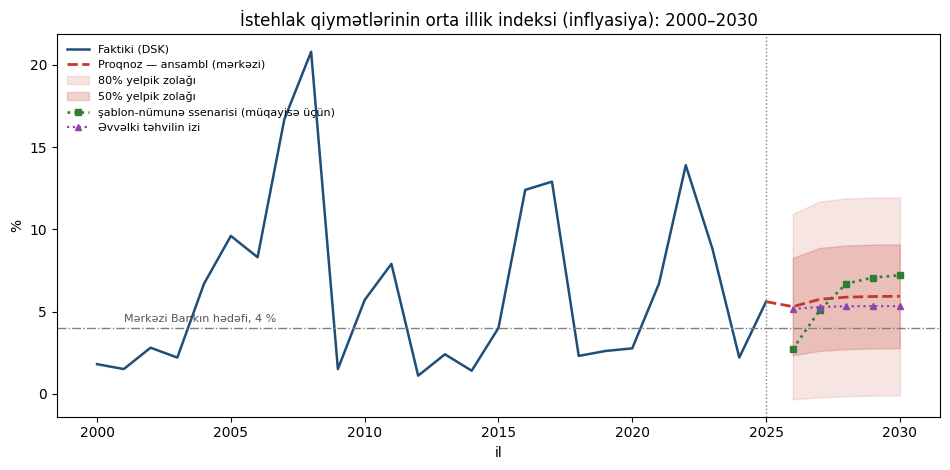

In [26]:
fig, ax = plt.subplots(figsize=(9.6, 4.8))
h = cpi_infl.loc[2000:]
ax.plot(h.index, h.values, "-", color="#1f4e79", lw=1.8, label="Faktiki (DSK)")
xx = [LA] + FY
ax.plot(xx, [last_pi] + list(central.values), "--", color="#c0392b", lw=2.0,
        label="Proqnoz — ansambl (mərkəzi)")
ax.fill_between(FY, bands["lo80"], bands["hi80"], color="#c0392b", alpha=0.13,
                label="80% yelpik zolağı")
ax.fill_between(FY, bands["lo50"], bands["hi50"], color="#c0392b", alpha=0.22,
                label="50% yelpik zolağı")
ax.plot(mb.index, mb.values, ":", color="#2e7d32", lw=1.9, marker="s", ms=4,
        label="şablon-nümunə ssenarisi (müqayisə üçün)")
ax.plot(prior.index, prior.values, ":", color="#8e44ad", lw=1.6, marker="^", ms=4,
        label="Əvvəlki təhvilin izi")
ax.axhline(4.0, color="grey", ls="-.", lw=1.0)
ax.annotate("Mərkəzi Bankın hədəfi, 4 %", xy=(2001, 4.35), fontsize=8, color="#555555")
ax.axvline(LA, color="grey", ls=":", lw=1)
ax.set_title("İstehlak qiymətlərinin orta illik indeksi (inflyasiya): 2000–2030")
ax.set_ylabel("%"); ax.set_xlabel("il")
ax.legend(loc="upper left", frameon=False, fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(config.FIG, "FR09_proqnoz.png"), dpi=140)
plt.show()

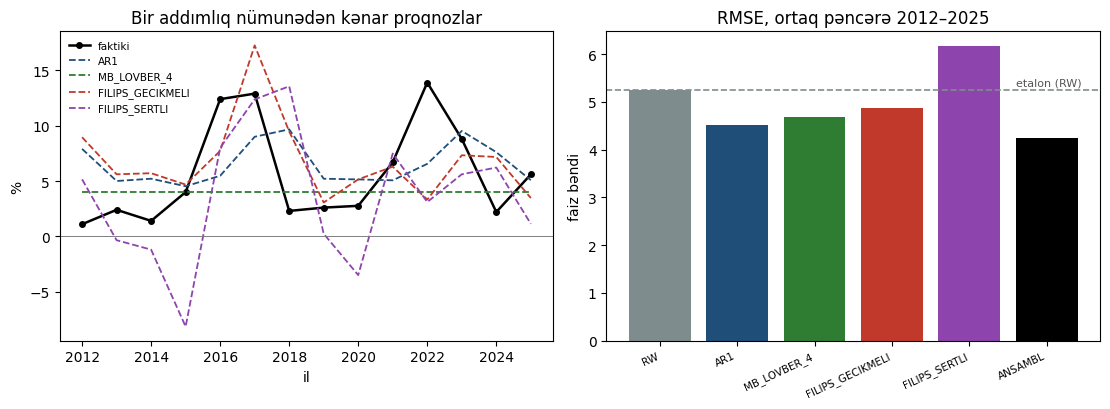

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.2))

ax = axes[0]
yrs = list(piv.index)
ax.plot(yrs, piv["faktiki"].values, "k-o", ms=4, lw=1.8, label="faktiki")
for m, colr in [("AR1", "#1f4e79"), ("MB_LOVBER_4", "#2e7d32"),
                ("FILIPS_GECIKMELI", "#c0392b"), ("FILIPS_SERTLI", "#8e44ad")]:
    ax.plot(yrs, piv[m].values, "--", lw=1.3, color=colr, label=m)
ax.axhline(0, color="grey", lw=0.7)
ax.set_title("Bir addımlıq nümunədən kənar proqnozlar")
ax.set_ylabel("%"); ax.set_xlabel("il")
ax.legend(frameon=False, fontsize=7.5)

ax = axes[1]
names = [m for m in ["RW", "AR1", "MB_LOVBER_4", "FILIPS_GECIKMELI", "FILIPS_SERTLI"]
         if bt.rmse.get(m) is not None]
vals = [bt.rmse[m] for m in names] + [bt.ensemble_rmse]
lbls = names + ["ANSAMBL"]
colr = ["#7f8c8d"] + ["#1f4e79", "#2e7d32", "#c0392b", "#8e44ad"][:len(names) - 1] + ["#000000"]
ax.bar(range(len(vals)), vals, color=colr)
ax.axhline(bt.rw_rmse, color="#7f8c8d", ls="--", lw=1.2)
ax.annotate("etalon (RW)", xy=(len(vals) - 1.4, bt.rw_rmse + 0.08), fontsize=8, color="#555555")
ax.set_xticks(range(len(vals)))
ax.set_xticklabels(lbls, rotation=25, ha="right", fontsize=7.5)
ax.set_title(f"RMSE, ortaq pəncərə {bt.common_years[0]}–{bt.common_years[-1]}")
ax.set_ylabel("faiz bəndi")
fig.tight_layout()
fig.savefig(os.path.join(config.FIG, "FR09_geriye_sinaq.png"), dpi=140)
plt.show()

### 7.4. Bazis indeksi və buraxılış qeydi

Orta illik artım tempi ilə yanaşı bazis indeksi də ixrac olunur, çünki aşağı axın FR-ləri (deflyator
zəncirləri, real gəlirlər) məhz səviyyə indeksi ilə işləyir. İndeks 2015 = 1,000 bazasında rəsmi
`cpi_infl` sırasından zəncirlə qurulur və nəşr olunmuş `cpi_index` sırası ilə tutuşdurulur.

In [28]:
chk = pd.DataFrame({"zəncirlə qurulmuş": cpi_index, "nəşr olunmuş": cpi_index_pub}).dropna()
chk["nisbi fərq, %"] = ((chk.iloc[:, 0] / chk.iloc[:, 1] - 1) * 100).round(6)
print("1995–2024 üzrə maksimal nisbi fərq: "
      f"{chk.loc[1995:LA - 1, 'nisbi fərq, %'].abs().max():.6f} %")
print(f"2025 üzrə nisbi fərq: {chk.loc[LA, 'nisbi fərq, %']:.3f} %")
chk.tail(6).round(6)

1995–2024 üzrə maksimal nisbi fərq: 0.000112 %
2025 üzrə nisbi fərq: 3.792 %


,zəncirlə qurulmuş,nəşr olunmuş,"nisbi fərq, %"
2020,1.368697,1.368696,0.000112
2021,1.460400,1.460398,0.000112
2022,1.663395,1.663393,0.000112
2023,1.809774,1.809772,0.000112
2024,1.849589,1.849587,0.000112
2025,1.953166,1.881812,3.791783


**Buraxılış qeydi (vintage).** Zəncir 1995–2024 illərində nəşr olunmuş indekslə praktik olaraq eyni
(maksimal nisbi fərq 0,0001 %-dən kiçik), 2025-ci ildə isə 3,79 % ayrılır. Səbəb aydındır və
gizlədilməməlidir: `model_series_annual.csv` faylının bazis indeksi 2025 üçün təxminən 1,74 %-lik artım
daşıyır, halbuki eyni faylın öz `cpi_infl` sütunu və DSK-nın rəsmi buraxılışı 5,6 % göstərir — yəni
indeks sırası rəsmi 2025 nəticəsindən əvvəlki buraxılışda dondurulub. Paketdə **rəsmi göstərici əsas
götürülür** və indeks ondan yenidən zəncirlənir; ixrac olunan `cpi_index` sırası bu yenidən qurulmuş
sıradır.

In [29]:
cpi_index_fc = pd.Series(dtype=float)
prev = float(cpi_index.loc[LA])
for y in FY:                     # zəncir: hər ilin indeksi əvvəlki il × (1 + π/100)
    prev = prev * (1 + float(central.loc[y]) / 100.0)
    cpi_index_fc.loc[y] = prev
print("İQİ bazis indeksi, proqnoz (2015 = 1,000):")
print(cpi_index_fc.round(4).to_string())
print(f"\n2025→2030 məcmu qiymət artımı: "
      f"{(cpi_index_fc.loc[FY[-1]] / cpi_index.loc[LA] - 1) * 100:.1f} %")

İQİ bazis indeksi, proqnoz (2015 = 1,000):
2026    2.0567
2027    2.1748
2028    2.3025
2029    2.4387
2030    2.5833

2025→2030 məcmu qiymət artımı: 32.3 %


## 8. Nəticələrin ixracı

Dörd çıxış faylı yazılır: vahid fərziyyə dəsti (`data/assumptions.csv`), proqnoz/faktiki sıralar
(`outputs/forecast_long.csv`), tənlik kataloqu (`outputs/equations_catalog.csv`) və artıq yuxarıda
yazılmış sınaq nəticələri (`outputs/validation_backtest.csv`). Sonda bütün eyniliklər HƏR il üçün
yoxlanılır.

In [30]:
NOTE_FC = ("FR09 ansamblı (AR1 0,360 + MB lövbəri 0,332 + gecikmiş Filips 0,308; çəkilər tərs-RMSE²), "
           "brent_usd və Δln NEER = 0 rejim fərziyyəsi ilə şərtləndirilmiş")
rows = [{"assumption_key": "cpi_infl", "year": int(y), "value": round(float(central.loc[y]), 4),
         "unit": "%", "note": NOTE_FC} for y in FY]
rows += [{"assumption_key": "cpi_infl_lo80", "year": int(y),
          "value": round(float(bands.loc[y, "lo80"]), 4), "unit": "%",
          "note": "80% yelpik zolağının aşağı sərhədi — OOS RMSE + parametr qeyri-müəyyənliyi"}
         for y in FY]
rows += [{"assumption_key": "cpi_infl_hi80", "year": int(y),
          "value": round(float(bands.loc[y, "hi80"]), 4), "unit": "%",
          "note": "80% yelpik zolağının yuxarı sərhədi — OOS RMSE + parametr qeyri-müəyyənliyi"}
         for y in FY]
rows += [{"assumption_key": "cbar_target", "year": int(y), "value": 4.0, "unit": "%",
          "note": "Mərkəzi Bankın elan etdiyi inflyasiya hədəfi — kalibrlənmiş lövbər (FR09)"}
         for y in FY]
assum = pd.DataFrame(rows)
outputs.write_assumptions(assum)
print(f"assumptions.csv: {len(assum)} sətir yazıldı (cpi_infl, cpi_infl_lo80, cpi_infl_hi80, "
      f"cbar_target)")
assum.head(5)

assumptions.csv: 20 sətir yazıldı (cpi_infl, cpi_infl_lo80, cpi_infl_hi80, cbar_target)


,assumption_key,year,value,unit,note
0,cpi_infl,2026,5.2991,%,"FR09 ansamblı (AR1 0,360 + MB lövbəri 0,332 + ..."
1,cpi_infl,2027,5.7416,%,"FR09 ansamblı (AR1 0,360 + MB lövbəri 0,332 + ..."
2,cpi_infl,2028,5.8752,%,"FR09 ansamblı (AR1 0,360 + MB lövbəri 0,332 + ..."
3,cpi_infl,2029,5.9149,%,"FR09 ansamblı (AR1 0,360 + MB lövbəri 0,332 + ..."
4,cpi_infl,2030,5.9278,%,"FR09 ansamblı (AR1 0,360 + MB lövbəri 0,332 + ..."


In [31]:
# DİNAMİKLİK GÖSTƏRİCİSİ
_dyn9 = [ek.sigma_ratio(central.reindex(FY), data_layer.actuals("cpi_infl"), series_code="cpi_infl",
                        label_az="İstehlak qiymətləri indeksi (inflyasiya)",
                        # DİQQƏT: mərkəzi yol hədəfə YIĞILMIR — 5,30 %-dən 5,93 %-ə qalxır, yəni
                        # 4 % hədəfindən uzaqlaşır (Bölmə 9). Aşağı dinamiklik göstəricisinin əsl
                        # səbəbi budur ki, üç komponentin ikisi (AR(1)-in tarazlığı və sabit lövbər)
                        # üfüq boyu praktiki olaraq sabitdir, ona görə ansambl yolu düzdür.
                        justification="mərkəzi yol üç komponentli ansambldır: AR(1) öz uzunmüddətli "
                                      "tarazlığına (6,6 %) yaxınlaşır, Mərkəzi Bankın lövbəri sabit "
                                      "4 %-dir, gecikmiş Filips isə yavaş qalxır — üç yolun çəkili "
                                      "cəmi 5,3-5,9 % aralığında demək olar düz gedir, ona görə "
                                      "proqnozun dəyişkənliyi faktiki sıranın (2015-16 devalvasiyası "
                                      "və 2022 şoku daxil) dəyişkənliyindən qat-qat kiçikdir",
                        dyn_class="qiymet")]
outputs.write_backtest(ek.dynamics_rows(_dyn9))
ek.assert_dynamics_band(_dyn9, strict=False)
outputs.publish_dynamics_notes(_dyn9)
print(f"DINAMIKLIK (cpi_infl): σ(proqnoz)={_dyn9[0].sd_forecast:.3f}, "
      f"σ(faktiki)={_dyn9[0].sd_actual:.3f}, nisbət={_dyn9[0].ratio:.3f}")


D2: 1 sıra üçün dinamiklik əsaslandırması seriya lüğətinə yazıldı
DINAMIKLIK (cpi_infl): σ(proqnoz)=0.236, σ(faktiki)=4.366, nisbət=0.054


In [32]:
NAME_PI = "İnflyasiya (İQİ, orta illik)"
NAME_IX = "İstehlak qiymətlərinin bazis indeksi (2015 = 1,000)"
fl = []

for y, v in cpi_infl.items():                       # faktiki inflyasiya
    fl.append({"fr": "FR9", "series_code": "cpi_infl", "series_name_az": NAME_PI, "unit": "%",
               "year": int(y), "kind": "actual", "source": "ours", "value": float(v),
               "lo80": None, "hi80": None, "lo50": None, "hi50": None})
for y in FY:                                        # proqnoz + yelpik zolaqları
    fl.append({"fr": "FR9", "series_code": "cpi_infl", "series_name_az": NAME_PI, "unit": "%",
               "year": int(y), "kind": "forecast", "source": "ours",
               "value": round(float(central.loc[y]), 4),
               "lo80": round(float(bands.loc[y, "lo80"]), 4),
               "hi80": round(float(bands.loc[y, "hi80"]), 4),
               "lo50": round(float(bands.loc[y, "lo50"]), 4),
               "hi50": round(float(bands.loc[y, "hi50"]), 4)})
for y, v in mb.items():                             # şablon-nümunə ssenarisi (overlay)
    fl.append({"fr": "FR9", "series_code": "cpi_infl", "series_name_az": NAME_PI, "unit": "%",
               "year": int(y), "kind": "forecast", "source": "template_sample", "value": float(v),
               "lo80": None, "hi80": None, "lo50": None, "hi50": None})
for y, v in cpi_index.items():                      # bazis indeksi — faktiki (yenidən zəncirlənmiş)
    fl.append({"fr": "FR9", "series_code": "cpi_index", "series_name_az": NAME_IX, "unit": "indeks",
               "year": int(y), "kind": "actual", "source": "ours", "value": round(float(v), 6),
               "lo80": None, "hi80": None, "lo50": None, "hi50": None})
for y, v in cpi_index_fc.items():                   # bazis indeksi — proqnoz
    fl.append({"fr": "FR9", "series_code": "cpi_index", "series_name_az": NAME_IX, "unit": "indeks",
               "year": int(y), "kind": "forecast", "source": "ours", "value": round(float(v), 6),
               "lo80": None, "hi80": None, "lo50": None, "hi50": None})

fl = pd.DataFrame(fl)

# --- BVF ETALON SƏTİRLƏRİ (R23) ------------------------------------------------------------
# `source=imf_reference`, sıranın sahibi FR9-dur. BU partiya ilə BİR çağırışda yazılır:
# `write_forecast_long` əhatəni `fr` üzrə yerinə-yazır, ayrıca çağırış FR9-un qalanını silərdi.
imf = data_layer.reference_rows(FY, {"cpi_infl": "FR9"})
fl = pd.concat([fl, imf], ignore_index=True)
print(f"BVF etalonu: {len(imf)} sətir, buraxılış — {data_layer.REFERENCE_VINTAGE_NOTE}")
outputs.write_forecast_long(fl)
print(f"forecast_long.csv: {len(fl)} sətir yazıldı "
      f"(cpi_infl: faktiki {len(cpi_infl)} + proqnoz {len(FY)} + Nazirlik {len(mb)}; "
      f"cpi_index: faktiki {len(cpi_index)} + proqnoz {len(FY)})")
fl.tail(4)

BVF etalonu: 5 sətir, buraxılış — BVF Maddə IV 26/112, aprel 2026 vintajı
forecast_long.csv: 87 sətir yazıldı (cpi_infl: faktiki 34 + proqnoz 5 + Nazirlik 5; cpi_index: faktiki 33 + proqnoz 5)


,fr,series_code,series_name_az,unit,year,kind,source,value,lo80,hi80,lo50,hi50
83,FR9,cpi_infl,"İnflyasiya (İQİ, orta illik)",%,2027,forecast,imf_reference,5.1,NaN,NaN,NaN,NaN
84,FR9,cpi_infl,"İnflyasiya (İQİ, orta illik)",%,2028,forecast,imf_reference,4.1,NaN,NaN,NaN,NaN
85,FR9,cpi_infl,"İnflyasiya (İQİ, orta illik)",%,2029,forecast,imf_reference,4.0,NaN,NaN,NaN,NaN
86,FR9,cpi_infl,"İnflyasiya (İQİ, orta illik)",%,2030,forecast,imf_reference,4.0,NaN,NaN,NaN,NaN


In [33]:
WB = "Statistik data dinamika 05.06.2026 +.xlsx"
cat_rows = pd.DataFrame([
    res_pc.catalog_row(
        eq_name="FR9_filips_baza",
        description=("STRUKTUR: açıq iqtisadiyyat Filips əyrisi — gözləntilər, neft xərc kanalı, "
                     "NEER ötürülməsi və 2015-16 devalvasiya süni dəyişəni"),
        lhs="cpi_infl", series_code="cpi_infl", fr="FR9", workbook=WB, sheet="Monetar sektoru"),
    res_pc_long.catalog_row(
        eq_name="FR9_filips_uzun_numune",
        description="ROBUSTLİK: eyni spesifikasiya 2001-2025 nümunəsində — nümunə seçiminin yoxlanması",
        lhs="cpi_infl", series_code="cpi_infl", fr="FR9", workbook=WB, sheet="Monetar sektoru"),
    res_pc_op.catalog_row(
        eq_name="FR9_filips_gecikmeli",
        description=("STRUKTUR (əməliyyat): yalnız gecikmiş sürücülərlə Filips əyrisi — real vaxtda "
                     "proqnoz verə bilən variant, ansamblda çəkisi 0,308"),
        lhs="cpi_infl", series_code="cpi_infl", fr="FR9", workbook=WB, sheet="Monetar sektoru"),
    res_diag.catalog_row(
        eq_name="FR9_filips_diaqnostik",
        description=("DİAQNOSTİK: output gap və real pul kütləsi ilə genişləndirmə — hər iki əmsal "
                     "sıfırdan fərqli deyil, baza spesifikasiyası saxlanılır"),
        lhs="cpi_infl", series_code="cpi_infl", fr="FR9", workbook=WB, sheet="Monetar sektoru"),
    res_ar1.catalog_row(
        eq_name="FR9_ar1_etalon",
        description=("ETALON: AR(1) orta qiymətə qayıdış — ansamblın ən ağır komponenti "
                     "(çəki 0,360), uzunmüddətli orta 6,6 %"),
        lhs="cpi_infl", series_code="cpi_infl", fr="FR9", workbook=WB, sheet="macro_annual.csv"),
])
outputs.write_equations_catalog(cat_rows)
cat_rows[["eq_name", "lhs", "rhs", "sample_start", "sample_end", "adj_r2", "se_regression"]]

,eq_name,lhs,rhs,sample_start,sample_end,adj_r2,se_regression
0,FR9_filips_baza,cpi_infl,pi_l1 + dlb + dln + d1516,2005,2025,0.2747,4.7459
1,FR9_filips_uzun_numune,cpi_infl,pi_l1 + dlb + dln + d1516,2001,2025,0.3402,4.3442
2,FR9_filips_gecikmeli,cpi_infl,pi_l1 + dlb_l1 + dln_l1 + d1516,2005,2025,-0.0808,5.7935
3,FR9_filips_diaqnostik,cpi_infl,pi_l1 + dlb + dln + d1516 + gap_l1 + dlrm2_l1,2008,2025,0.2471,4.7622
4,FR9_ar1_etalon,cpi_infl,pi_l1,2000,2025,0.1154,5.0043


In [34]:
v = validate.Verifier("FR09 — İnflyasiya (İQİ)")

# 1. zəncir eyniliyi: bazis indeksi = əvvəlki il × (1 + π/100), üfüqün HƏR ilində
chain_lhs = cpi_index_fc
chain_rhs = pd.Series({y: (float(cpi_index.loc[LA]) if y == FY[0] else float(cpi_index_fc.loc[y - 1]))
                       * (1 + float(central.loc[y]) / 100.0) for y in FY})
v.identity("İQİ zənciri 2026-2030: indeks(t) = indeks(t-1) × (1 + π(t)/100)",
           chain_lhs, chain_rhs, tol=1e-12)

# 2. tarixi zəncir nəşr olunmuş indekslə üst-üstə düşür (2025 buraxılış fərqi istisna olmaqla)
v.identity("Tarixi İQİ zənciri nəşr olunmuş sıra ilə üst-üstə düşür (1995-2024)",
           cpi_index.loc[1995:LA - 1], cpi_index_pub.loc[1995:LA - 1], tol=1e-5, rel_tol=1e-5)

# 3. ansambl çəkilərinin cəmi vahidə bərabərdir
v.close("Ansambl çəkilərinin cəmi = 1", sum(bt.weights.values()), 1.0, tol=1e-12)

# 4. mərkəzi yol çəkili cəmdir — müstəqil yenidən hesablama
v.identity("Mərkəzi yol = Σ çəki(m) × yol(m), hər il",
           central, pd.Series({y: sum(bt.weights[m] * paths[m][y] for m in bt.weights) for y in FY}),
           tol=1e-12)

# 5. 2026 mərkəzi dəyəri ilkin girişlərdən tamamilə müstəqil kodla yenidən törədilir
def _yenidən_hesabla_2026():
    d = S.loc[2000:LA, ["y", "pi_l1"]].dropna()
    X = np.column_stack([np.ones(len(d)), d["pi_l1"].values])
    b = np.linalg.lstsq(X, d["y"].values, rcond=None)[0]
    ar = b[0] + b[1] * last_pi
    d2 = S.loc[2005:LA, ["y", "pi_l1", "dlb_l1", "dln_l1", "d1516"]].dropna()
    X2 = np.column_stack([np.ones(len(d2)), d2[["pi_l1", "dlb_l1", "dln_l1", "d1516"]].values])
    b2 = np.linalg.lstsq(X2, d2["y"].values, rcond=None)[0]
    pcl = b2[0] + b2[1] * last_pi + b2[2] * dlb_lag[FY[0]] + b2[3] * dln_lag[FY[0]]
    return (bt.weights["AR1"] * ar + bt.weights["MB_LOVBER_4"] * 4.0
            + bt.weights["FILIPS_GECIKMELI"] * pcl)

v.recompute("2026 mərkəzi inflyasiya (müstəqil OLS ilə yenidən törədilir)",
            shipped=float(central.loc[FY[0]]), fn=_yenidən_hesabla_2026, tol=1e-8)

# 6. yelpik zolağı mərkəzi yolu əhatə edir, düzgün sıralanır və üfüq boyu MONOTON genişlənir
v.ok("80% zolağı mərkəzi yolu əhatə edir",
     bool(((bands["lo80"] < central) & (bands["hi80"] > central)).all()),
     f"minimal genişlik {float((bands['hi80'] - bands['lo80']).min()):.2f} p.b.")
v.ok("zolaq düzgün sıralanıb (lo80 ≤ lo50 ≤ mərkəz ≤ hi50 ≤ hi80)",
     bool((bands["lo80"] <= bands["lo50"]).all() and (bands["lo50"] <= central).all()
          and (central <= bands["hi50"]).all() and (bands["hi50"] <= bands["hi80"]).all()))
# σ_h tərifinə görə h ilə artır, ona görə zolaq da artmalıdır; əvvəlki buraxılışda hər il ayrı
# toxumla çəkildiyi üçün bu şərt POZULURDU (2030 < 2029). İndi yoxlanılır.
_en80 = (bands["hi80"] - bands["lo80"])
v.ok("zolaq üfüq boyu monoton genişlənir",
     bool((_en80.diff().dropna() > 0).all()),
     f"en: {_en80.round(3).tolist()}")

# 6b. simulyasiya nəticəsi analitik normal kvantillərlə uzlaşır (qalıq + parametr — hər ikisi normal,
#     ona görə dəqiq düstur məlumdur; simulyasiyanın yeganə töhfəsi Monte-Karlo səhvidir)
_prev_a, _an_rows = last_pi, {}
for _h, _y in enumerate(FY, start=1):
    _sig = sigma1 * float(np.sqrt(sum(rho ** (2 * j) for j in range(_h))))
    _x = np.array([1.0, _prev_a, dlb_lag[_y], dln_lag[_y], 0.0])
    _sd = float(np.sqrt(_sig ** 2 + float(_x @ cov_op @ _x)))
    _an_rows[_y] = {"lo80": central.loc[_y] - 1.2816 * _sd, "hi80": central.loc[_y] + 1.2816 * _sd,
                    "lo50": central.loc[_y] - 0.6745 * _sd, "hi50": central.loc[_y] + 0.6745 * _sd}
    _prev_a = paths["FILIPS_GECIKMELI"][_y]
_an = pd.DataFrame(_an_rows).T
_mc_err = float((bands[["lo80", "hi80", "lo50", "hi50"]] - _an).abs().max().max())
v.ok("simulyasiya zolağı analitik normal kvantillərlə uzlaşır (≤ 0,10 f.b.)",
     bool(_mc_err <= 0.10), f"maksimal fərq {_mc_err:.4f} f.b. (ndraw = 200 000, ortaq toxum)")

# 7. gələcəyə baxış yoxdur — qiymətləndirmə nümunələri VƏ sınaq pəncərələri
v.no_lookahead("Filips (baza/əməliyyat) qiymətləndirmə nümunəsi", sA.index)
v.no_lookahead("AR(1) qiymətləndirmə nümunəsi", sAR.index)
v.no_lookahead("diaqnostik qiymətləndirmə nümunəsi", sD.index)
v.no_lookahead("geriyə doğru sınaq pəncərəsi (əsas)", pd.Index(bt.common_years))
v.no_lookahead("geriyə doğru sınaq pəncərəsi (dinamika formaları)", pd.Index(bt_dyn9.common_years))

v.assert_all()

  YOXLAMA: FR09 — İnflyasiya (İQİ)
  [PASS] eynilik: İQİ zənciri 2026-2030: indeks(t) = indeks(t-1) × (1 + π(t)/100)
         5 il, maksimal fərq 0.000e+00
  [PASS] eynilik: Tarixi İQİ zənciri nəşr olunmuş sıra ilə üst-üstə düşür (1995-2024)
         30 il, maksimal fərq 2.076e-06
  [PASS] Ansambl çəkilərinin cəmi = 1
         maksimal fərq 0.000e+00 ≤ 1.0e-12
  [PASS] eynilik: Mərkəzi yol = Σ çəki(m) × yol(m), hər il
         5 il, maksimal fərq 8.882e-16
  [PASS] yenidən hesablama: 2026 mərkəzi inflyasiya (müstəqil OLS ilə yenidən törədilir)
         maksimal fərq 8.882e-16 ≤ 1.0e-08
  [PASS] 80% zolağı mərkəzi yolu əhatə edir
         minimal genişlik 11.27 p.b.
  [PASS] zolaq düzgün sıralanıb (lo80 ≤ lo50 ≤ mərkəz ≤ hi50 ≤ hi80)
  [PASS] zolaq üfüq boyu monoton genişlənir
         en: [11.27, 11.921, 12.019, 12.045, 12.049]
  [PASS] simulyasiya zolağı analitik normal kvantillərlə uzlaşır (≤ 0,10 f.b.)
         maksimal fərq 0.0239 f.b. (ndraw = 200 000, ortaq toxum)
  [PASS] gələcə

In [35]:
# Yazılmış sətirlərin diskdə həqiqətən yerləşdiyinin yoxlanması
fl_disk = pd.read_csv(os.path.join(config.OUT, "forecast_long.csv"))
as_disk = pd.read_csv(config.ASSUMPTIONS)
eq_disk = pd.read_csv(os.path.join(config.OUT, "equations_catalog.csv"))
bt_disk = pd.read_csv(os.path.join(config.OUT, "validation_backtest.csv"))
print("forecast_long.csv, FR9 sətirləri:      ", int((fl_disk["fr"] == "FR9").sum()))
print("assumptions.csv, cpi_infl sətirləri:   ",
      int(as_disk["assumption_key"].str.startswith("cpi_infl").sum()))
print("assumptions.csv, cbar_target sətirləri:", int((as_disk["assumption_key"] == "cbar_target").sum()))
print("equations_catalog.csv, FR9 sətirləri:  ", int((eq_disk["fr"] == "FR9").sum()))
print("validation_backtest.csv, cpi_infl:     ", int((bt_disk["series_code"] == "cpi_infl").sum()))
print("\nFərziyyə dəstinin açarları:", sorted(as_disk["assumption_key"].unique()))

forecast_long.csv, FR9 sətirləri:       87
assumptions.csv, cpi_infl sətirləri:    15
assumptions.csv, cbar_target sətirləri: 5
equations_catalog.csv, FR9 sətirləri:   5
validation_backtest.csv, cpi_infl:      84

Fərziyyə dəstinin açarları: ['brent_usd', 'brent_usd_hi80', 'brent_usd_lo80', 'cbar_target', 'cpi_infl', 'cpi_infl_hi80', 'cpi_infl_lo80', 'drv_agri_g', 'drv_constr_state_g', 'drv_constr_works_g', 'drv_ict_exp_g', 'drv_ict_subs_g', 'drv_manuf_g', 'drv_power_g', 'drv_social_g', 'drv_social_pens_g', 'drv_tourism_bop_g', 'drv_tourism_g', 'drv_trade_g', 'drv_transport_g', 'drv_water_g', 'drv_water_pop_g', 'eur_azn', 'eur_azn_hi80', 'eur_azn_lo80', 'fr02_nonoil_demand_used', 'g_cons_core', 'g_income_core', 'g_inv_core', 'gas_export_price', 'gdp_defl', 'gdp_realg', 'import_price_infl', 'inv_foreign_realg', 'm2_real_g', 'nonoil_defl', 'nonoil_defl_demand', 'nonoil_realg', 'nonoil_realg_demand', 'nonoil_realg_demand_hi80', 'nonoil_realg_demand_lo80', 'nonoil_realg_hi80', 'nonoil_real

## 9. Məhdudiyyətlər

**BVF etalonunun buraxılış şərtiliyi (əvvəlki DATA-GAP bağlanıb).** Azərbaycanın İQİ proqnozu üçün
beynəlxalq istinad artıq identifikasiya olunub və §7.3-də müqayisəyə daxildir: BVF Maddə IV
məsləhətləşməsinin ölkə hesabatı 26/112, Cədvəl 1 (WEO yolu eyni rəqəmi verir). İstinadın
məhdudiyyəti mənbənin olmaması deyil, onun BURAXILIŞA bağlılığıdır: rəqəmlər **BVF Maddə IV 26/112, aprel 2026 vintajı**-na aiddir və
BVF hər raundda onları yeniləyir, ona görə müqayisə yalnız həmin buraxılış qeydi ilə birlikdə
oxunmalıdır. Xarici blokdakı `core_cpi_infl` sütunu isə əvvəlki kimi istifadə olunmur — mənbəyi və
ölkə əhatəsi sənədləşdirilməyib.

**İş kitabının inflyasiya sətirləri başqa anlayışdadır.** Monetar sektorun 86–89-cu sətirlərinin illik
xanaları **dekabrdan dekabra** 12 aylıq artımdır, spesifikasiyanın tələb etdiyi orta illik göstərici
deyil (§2). İki anlayış bəzi illərdə 5–7 faiz bəndi fərqlənir (2021: 12,0 ↔ 6,7; 2023: 2,1 ↔ 8,8), ona
görə həmin sətirlər **uzlaşma sınağı kimi işlədilmir**: onlar yalnız strukturun (qrup üzrə hərəkətin)
təsviri üçündür və heç bir tənliyə daxil olmur. Baş göstərici bütövlükdə DSK-nın rəsmi orta illik
sırasından gəlir.

**Yelpik zolağının komponentləri vahid modeldən deyil.** σ₁ ansamblın sınaq xətasıdır, ρ AR(1)
etalonunun əmsalıdır (fərqli tənlik və nümunə), parametr kovariasiyası isə əməliyyat tənliyinindir və
onun ansambldakı 0,308 çəkisi nəzərə alınmadan tam gücü ilə tətbiq olunur. Hər üç seçim ayrılıqda
əsaslandırıla bilər, lakin birlikdə dəqiq ehtimal paylanması vermir — zolaq ölçülmüş qeyri-müəyyənliyin
**konservativ yaxınlaşmasıdır**. Parametr komponenti ümumi dispersiyanın yalnız ~7 %-ni təşkil etdiyi
üçün bu seçimlərin zolağın eninə təsiri kiçikdir (§7.2).

**DATA-GAP: aylıq İQİ panelinin əhatəsi.** `monthly_panel.csv` 2024-cü ilin dekabrında bitir, ona görə
2025-ci ilin aylıq strukturu yalnız əsas iş kitabının Monetar sektoru blokundan oxunur. Bu, illik
göstəriciyə təsir etmir (rəsmi orta illik dəyər müstəqil mənbədən gəlir), lakin ay-bə-ay təhlilin
dərinliyini məhdudlaşdırır.

**Buraxılış uyğunsuzluğu.** `model_series_annual.csv` faylının bazis indeksi 2025-ci il üçün rəsmi
inflyasiya nəticəsindən əvvəlki buraxılışda dondurulub (fərq 3,79 %). İxrac olunan indeks rəsmi
`cpi_infl` sırasından yenidən zəncirlənib; köhnə dəyər heç bir hesablamada istifadə olunmur.

**Nümunə uzunluğu.** Baza tənliyi n = 21 müşahidə üzərində qurulub və beş parametr daşıyır. Bu, illik
makro məlumat üçün adi vəziyyətdir, lakin əmsalların dəqiqliyini məhdudlaşdırır: NEER-in ötürülmə
əmsalı cari ildə statistik cəhətdən sıfırdan fərqli deyil, yalnız bir il gecikmə ilə zəif əhəmiyyət
qazanır (t = −1,85). Diaqnostik genişləndirmədə (n = 18, altı parametr) heç bir əlavə kanal
identifikasiya olunmur.

**Δln NEER-in stasionarlığı.** Sınaq nümunəsində Δln NEER üçün vahid kök hipotezi rədd edilmir
(p = 0,148). Bu, 2021-ci ildən sonrakı davamlı effektiv möhkəmlənmə dövrünün qısa nümunədə yaratdığı
nəticədir. Proqnoz üfüqündə həmin dəyişən rejim fərziyyəsi ilə sıfırlandığı üçün nəticəyə təsiri
məhduddur (həssaslıq: 2030-cu ildə 0,3 faiz bəndi).

**Sınıq nöqtələr.** 2015–2016-cı illərin devalvasiyası süni dəyişənlə idarə olunur; 2020-ci ilin
pandemiyası və 2022-ci ilin qlobal qiymət şoku üçün ayrıca süni dəyişən daxil edilməyib, çünki n = 21
nümunədə üç ayrı sınıq nöqtə dəyişəni sərbəstlik dərəcəsini tükədərdi. Bunun əvəzinə həmin illərin
qalıqları yelpik zolağının eninə daxil olur — zolaq məhz buna görə genişdir (80 % zolağı 2026-cı ildə
təxminən ±5,7 faiz bəndi).

**Mərkəzi yolun səviyyəsi.** Ansamblın verdiyi 5,3 → 5,9 % yolu Mərkəzi Bankın 4 % hədəfindən yuxarıdır.
Bu, hədəfin əlçatmaz olduğu iddiası deyil, məlumatın nə dediyinin qeydidir: 2000–2025 nümunəsində
inflyasiya 6,6 % ətrafında bir tarazlığa qayıdıb və hədəf lövbəri ansamblda cəmi 0,332 çəki alıb, çünki
sınaqda tək başına AR(1)-dən zəif çıxıb. Hədəfin tam etibarlılığı fərz edilsəydi, mərkəzi yol
4 %-ə yaxınlaşardı; belə bir fərziyyə üçün paketdə empirik əsas yoxdur.

**Proqnozun şərtiliyi.** Bütün yol iki ekzogen girişə şərtlənib: FR5-in neft qiyməti yolu (2026–2030
üçün 69 USD/barel ətrafında) və FR10-un məzənnə rejimi (1,70). Neft qiymətinin FR5 yelpiyinin aşağı
sərhədinə (2030-cu ildə 27 USD/barel) düşməsi və ya məzənnə rejiminin dəyişməsi bu proqnozu
qüvvədən salar; birinci halın ölçüsü Bölmə 5-in neft əmsalından (0,111) hesablana bilər.